# Mathematical Framework of the Contextual Manifold Architecture (v10.1)

## A PhD-Level Exposition with Diagnostic Audit

**Author:** David Ledbetter
**Date:** March 2026

---

This document provides a rigorous mathematical treatment of the v10.1 architecture,
connecting each computational component to its formal mathematical object. Every diagram
is generated from first principles to build geometric intuition.

**Structure:**
1. Fiber Bundles — the representational substrate
2. Parallel Transport and the Wilson Line — context accumulation
3. The SSM-Gauge Correspondence — why the parallel scan IS the Wilson line
4. Hopfield Energy Landscapes — context-dependent attractor dynamics
5. Curvature and Adaptive Routing — geometry-aware memory selection
6. The Pure Langevin SDE — thermodynamic settling
7. Diagnostic Audit — what the v10.1 training metrics reveal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib import cm

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'mathtext.fontset': 'cm',
})

class Arrow3D(FancyArrowPatch):
    """3D arrow for fiber bundle diagrams."""
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)

print("Visualization tools loaded.")

Visualization tools loaded.


## 1. Fiber Bundles — The Representational Substrate

### Definition

A **fiber bundle** is a triple (E, M, pi) where:
- **M** is the **base manifold** — the space of contextual coordinates
- **F** is the **fiber** — the local representational space at each point
- **E** is the **total space** — the union of all fibers: E = union over q in M of F_q
- **pi: E -> M** is the projection map

In a standard Transformer, all tokens live in the same R^d. There is no notion of
"where" in context space a token's representation lives — the geometry is globally flat.

In the Vega architecture, each token at contextual coordinate q lives in
its own fiber F_q. The fiber is decomposed into K orthogonal **subbundles**:

    F_q = F_q^(1) + F_q^(2) + ... + F_q^(K)

A token's representation is a **section** of this bundle: a choice of point in
each fiber along the base manifold.

### The Key Distinction

- **Flat geometry** (Transformer): All tokens in the same R^d. "Position 5" and
  "Position 50" use the same vector space. Context is added via attention.
- **Bundle geometry** (Vega): Token at position t lives in fiber F_{q_t} where
  q_t depends on the entire history x_0, ..., x_t. The representational space
  itself varies with context.

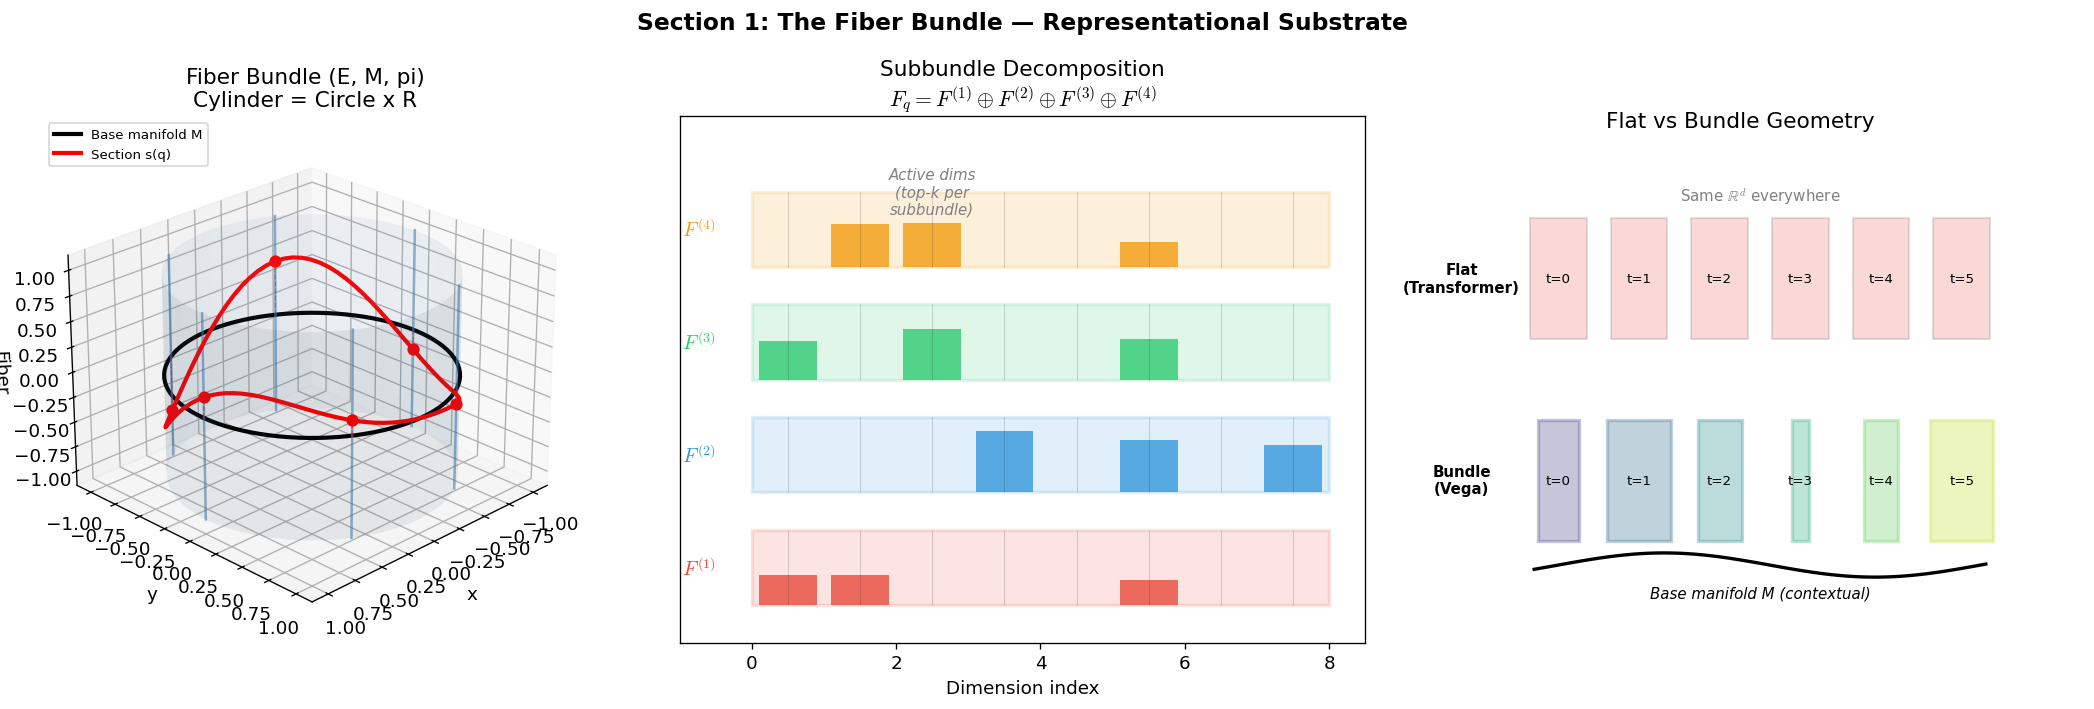

In [2]:
fig = plt.figure(figsize=(18, 6))

# --- Panel 1: The trivial bundle (cylinder) ---
ax1 = fig.add_subplot(131, projection='3d')

theta = np.linspace(0, 2 * np.pi, 100)
z_fiber = np.linspace(-1, 1, 20)
Theta, Z = np.meshgrid(theta, z_fiber)
X_cyl = np.cos(Theta)
Y_cyl = np.sin(Theta)
ax1.plot_surface(X_cyl, Y_cyl, Z, alpha=0.08, color='steelblue')

# Base manifold (circle at z=0)
ax1.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), 'k-', lw=2.5, label='Base manifold M')

# Sample fibers at specific points
fiber_angles = [0, np.pi/3, 2*np.pi/3, np.pi, 4*np.pi/3, 5*np.pi/3]
for a in fiber_angles:
    x0, y0 = np.cos(a), np.sin(a)
    ax1.plot([x0, x0], [y0, y0], [-1, 1], 'steelblue', lw=1.5, alpha=0.6)

# A section (curve on the cylinder)
section_z = 0.4 * np.sin(2 * theta) + 0.2 * np.cos(3 * theta)
ax1.plot(np.cos(theta), np.sin(theta), section_z, 'r-', lw=2.5, label='Section s(q)')

# Mark fiber points where section intersects
for a in fiber_angles:
    x0, y0 = np.cos(a), np.sin(a)
    z0 = 0.4 * np.sin(2 * a) + 0.2 * np.cos(3 * a)
    ax1.scatter([x0], [y0], [z0], c='red', s=40, zorder=5)
    ax1.plot([x0, x0], [y0, y0], [0, z0], 'r--', lw=0.8, alpha=0.5)

ax1.set_title('Fiber Bundle (E, M, pi)\nCylinder = Circle x R')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('Fiber')
ax1.view_init(elev=25, azim=45)

# --- Panel 2: Subbundle decomposition ---
ax2 = fig.add_subplot(132)

K = 4  # subbundles
d = 8  # fiber dim per subbundle
colors_sub = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for k in range(K):
    y_base = k * 1.5
    ax2.add_patch(plt.Rectangle((0, y_base), d, 1, facecolor=colors_sub[k], alpha=0.15, edgecolor=colors_sub[k], lw=2))
    ax2.text(-0.5, y_base + 0.5, f'$F^{{({k+1})}}$', fontsize=12, ha='right', va='center', color=colors_sub[k])

    np.random.seed(42 + k)
    active = sorted(np.random.choice(d, 3, replace=False))
    for i in range(d):
        if i in active:
            val = np.random.uniform(0.3, 0.9)
            ax2.bar(i + 0.5, val, width=0.8, bottom=y_base, color=colors_sub[k], alpha=0.8)
        ax2.plot([i + 0.5, i + 0.5], [y_base, y_base + 1], 'k-', lw=0.3, alpha=0.3)

ax2.set_xlim(-1, d + 0.5)
ax2.set_ylim(-0.5, K * 1.5 + 0.5)
ax2.set_xlabel('Dimension index')
ax2.set_title('Subbundle Decomposition\n$F_q = F^{(1)} \\oplus F^{(2)} \\oplus F^{(3)} \\oplus F^{(4)}$')
ax2.set_yticks([])

# Annotation: sparse activation
ax2.annotate('Active dims\n(top-k per\nsubbundle)', xy=(2.5, 5.2), fontsize=9,
             ha='center', style='italic', color='gray')

# --- Panel 3: Flat vs Bundle geometry ---
ax3 = fig.add_subplot(133)

positions = np.arange(6)
labels = ['t=0', 't=1', 't=2', 't=3', 't=4', 't=5']

# Flat: all in same R^d
for i, p in enumerate(positions):
    ax3.add_patch(plt.Rectangle((p - 0.35, 2.5), 0.7, 1.5, facecolor='lightcoral', alpha=0.3, edgecolor='gray'))
    ax3.text(p, 3.25, labels[i], ha='center', va='center', fontsize=8)
ax3.text(-1.2, 3.25, 'Flat\n(Transformer)', ha='center', va='center', fontsize=9, fontweight='bold')
ax3.annotate('Same $\\mathbb{R}^d$ everywhere', xy=(2.5, 4.2), fontsize=9, ha='center', color='gray')

# Bundle: each in different fiber
np.random.seed(0)
fiber_widths = [0.5 + 0.3 * np.sin(i * 1.5) for i in range(6)]
fiber_colors = plt.cm.viridis(np.linspace(0.2, 0.9, 6))
for i, p in enumerate(positions):
    w = fiber_widths[i]
    ax3.add_patch(plt.Rectangle((p - w/2, 0), w, 1.5, facecolor=fiber_colors[i], alpha=0.3, edgecolor=fiber_colors[i], lw=2))
    ax3.text(p, 0.75, labels[i], ha='center', va='center', fontsize=8)
ax3.text(-1.2, 0.75, 'Bundle\n(Vega)', ha='center', va='center', fontsize=9, fontweight='bold')

# Curved base manifold connecting bottom fibers
curve_x = np.linspace(-0.3, 5.3, 100)
curve_y = -0.3 + 0.15 * np.sin(curve_x * 1.2)
ax3.plot(curve_x, curve_y, 'k-', lw=2)
ax3.text(2.5, -0.7, 'Base manifold M (contextual)', ha='center', fontsize=9, style='italic')

ax3.set_xlim(-2, 6.5)
ax3.set_ylim(-1, 5)
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('Flat vs Bundle Geometry')

plt.suptitle('Section 1: The Fiber Bundle — Representational Substrate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Parallel Transport and the Wilson Line

### The Problem of Comparing Vectors in Different Fibers

In flat R^d, adding two vectors is trivial: v + w. But in a fiber bundle,
vectors at different base points live in *different vector spaces*. To compare or combine
them, we need **parallel transport** — a rule for moving a vector from one fiber to another
along a path on the base manifold.

### The Gauge Connection

A **connection** A is a rule that specifies how to transport vectors between
neighboring fibers. Given a path gamma from q_1 to q_2, the transport is:

    v_{q_2} = U(gamma) * v_{q_1}

where U(gamma) is the **parallel transport operator** (or **holonomy**). For a
U(1) gauge connection (phase rotations), this becomes the **Wilson line**:

    U(gamma) = P * exp(i * integral_gamma A)

where P denotes path-ordering (the order of the integral matters when the
connection is non-Abelian).

### Path Dependence = Context Sensitivity

The critical property: if you transport around a **closed loop**, the result is
generally NOT the identity. The discrepancy is the **holonomy**, and it measures
the **curvature** of the connection. Nonzero curvature means the result depends
on the *path*, not just the endpoints.

This is exactly **context sensitivity**: the representation of a token depends not
just on its position, but on the *path of tokens that led there*.

### The Classic Example: Transport on a Sphere

A tangent vector transported around a triangle on a sphere rotates by an angle
equal to the enclosed solid angle. This rotation IS the holonomy — the
accumulated effect of curvature along the path.

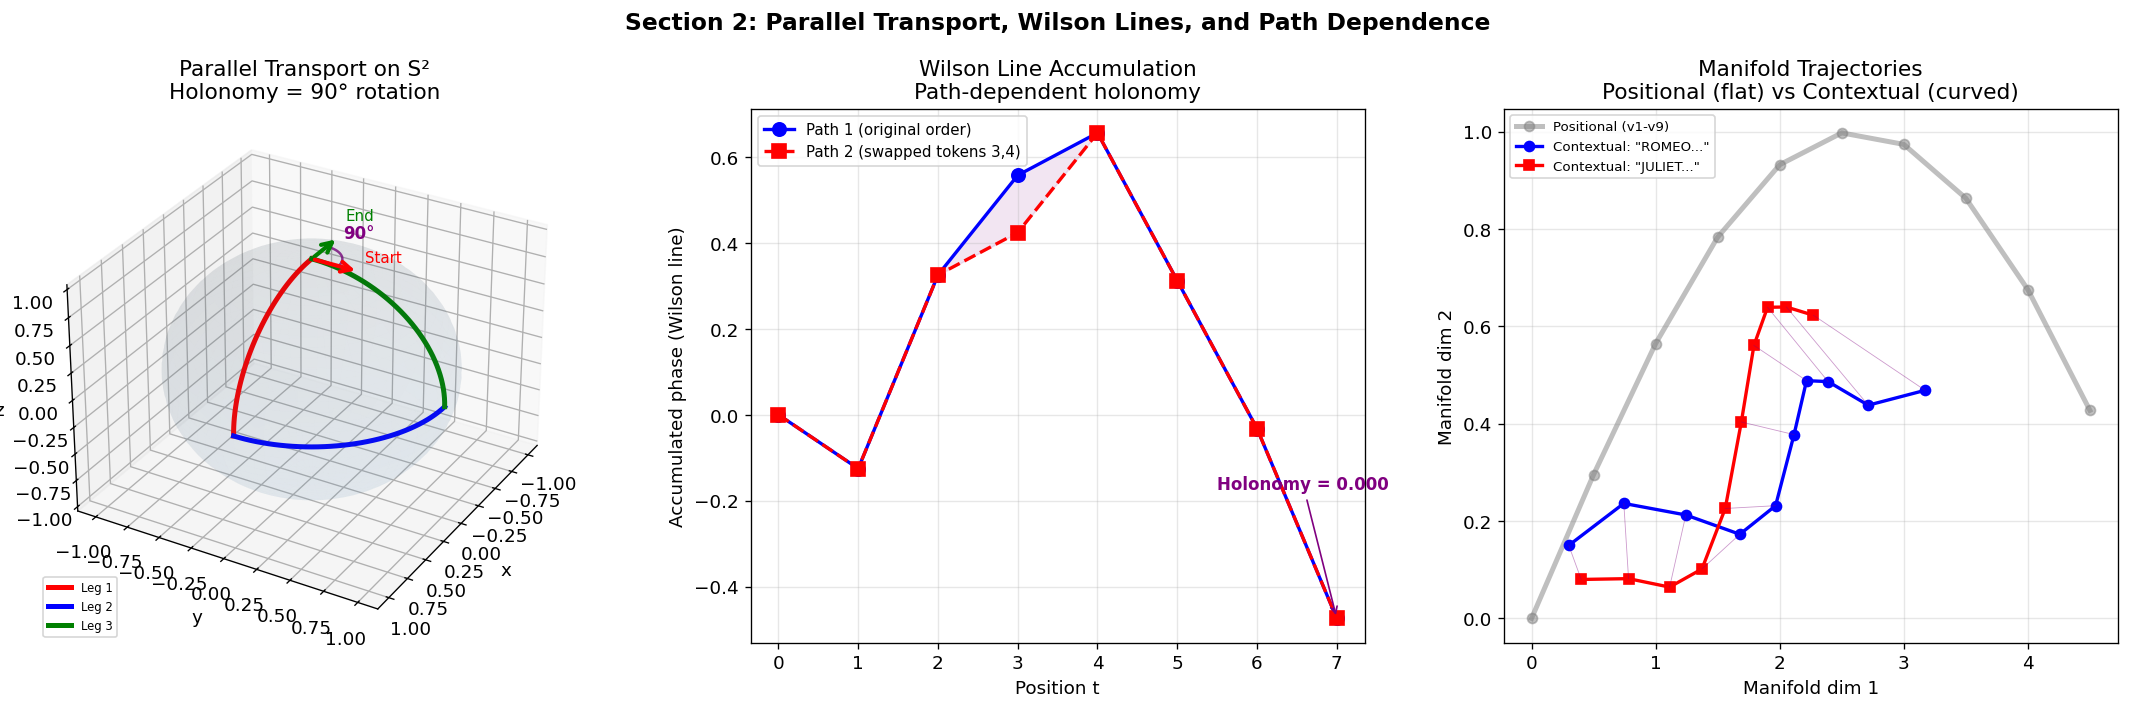

In [3]:
fig = plt.figure(figsize=(18, 6))

# --- Panel 1: Parallel transport on a sphere ---
ax1 = fig.add_subplot(131, projection='3d')

u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 40)
U, V = np.meshgrid(u, v)
Xs = np.cos(U) * np.sin(V)
Ys = np.sin(U) * np.sin(V)
Zs = np.cos(V)
ax1.plot_surface(Xs, Ys, Zs, alpha=0.06, color='steelblue')

# Triangle on sphere (geodesics)
# North pole -> equator (0) -> equator (pi/2) -> north pole
n_pts = 40
# Leg 1: North pole to equator at lon=0
lat1 = np.linspace(np.pi/2, 0, n_pts)
lon1 = np.zeros(n_pts)
# Leg 2: Along equator from lon=0 to lon=pi/2
lat2 = np.zeros(n_pts)
lon2 = np.linspace(0, np.pi/2, n_pts)
# Leg 3: Equator at lon=pi/2 back to north pole
lat3 = np.linspace(0, np.pi/2, n_pts)
lon3 = np.full(n_pts, np.pi/2)

def sph_to_cart(lat, lon):
    return np.cos(lon)*np.cos(lat), np.sin(lon)*np.cos(lat), np.sin(lat)

for lat, lon, color, label in [(lat1, lon1, 'red', 'Leg 1'),
                                 (lat2, lon2, 'blue', 'Leg 2'),
                                 (lat3, lon3, 'green', 'Leg 3')]:
    x, y, z = sph_to_cart(lat, lon)
    ax1.plot(x, y, z, color=color, lw=3, label=label)

# Transport vector: starts pointing East at north pole
# After transport around triangle, it rotates 90 degrees
arrow_scale = 0.35
xn, yn, zn = sph_to_cart(np.pi/2, 0)

# Initial vector (pointing in y direction at north pole)
a1 = Arrow3D([xn, xn], [yn, yn + arrow_scale], [zn, zn],
             mutation_scale=15, lw=2.5, arrowstyle='->', color='red')
ax1.add_artist(a1)
ax1.text(xn, yn + arrow_scale + 0.05, zn + 0.1, 'Start', fontsize=9, color='red')

# Final vector (pointing in -x direction at north pole, rotated 90 deg)
a2 = Arrow3D([xn, xn - arrow_scale], [yn, yn], [zn, zn],
             mutation_scale=15, lw=2.5, arrowstyle='->', color='green')
ax1.add_artist(a2)
ax1.text(xn - arrow_scale - 0.1, yn, zn + 0.1, 'End', fontsize=9, color='green')

# Angle arc
arc_t = np.linspace(0, np.pi/2, 20)
arc_r = 0.2
ax1.plot(xn + arc_r * (-np.sin(arc_t)), yn + arc_r * np.cos(arc_t),
         np.full(20, zn), 'purple', lw=1.5, alpha=0.8)
ax1.text(xn - 0.15, yn + 0.15, zn + 0.15, '90°', fontsize=10, color='purple', fontweight='bold')

ax1.set_title('Parallel Transport on S²\nHolonomy = 90° rotation')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.view_init(elev=30, azim=30)
ax1.legend(fontsize=7, loc='lower left')

# --- Panel 2: Wilson line accumulation ---
ax2 = fig.add_subplot(132)

T = 8
positions = np.arange(T)
np.random.seed(42)

# Connection values (phase shifts between consecutive positions)
A_values = np.random.uniform(-0.5, 0.5, T - 1)

# Accumulated phase (Wilson line)
phases = np.zeros(T)
for t in range(1, T):
    phases[t] = phases[t-1] + A_values[t-1]

# Two different paths (different token orderings) to same endpoint
A_alt = A_values.copy()
A_alt[2], A_alt[3] = A_alt[3], A_alt[2]  # swap two connection values
phases_alt = np.zeros(T)
for t in range(1, T):
    phases_alt[t] = phases_alt[t-1] + A_alt[t-1]

ax2.plot(positions, phases, 'b-o', lw=2, ms=8, label='Path 1 (original order)')
ax2.plot(positions, phases_alt, 'r--s', lw=2, ms=8, label='Path 2 (swapped tokens 3,4)')
ax2.fill_between(positions, phases, phases_alt, alpha=0.1, color='purple')

# Annotate holonomy
holonomy = abs(phases[-1] - phases_alt[-1])
ax2.annotate(f'Holonomy = {holonomy:.3f}',
             xy=(T-1, (phases[-1] + phases_alt[-1])/2),
             xytext=(T-2.5, max(phases[-1], phases_alt[-1]) + 0.3),
             fontsize=10, fontweight='bold', color='purple',
             arrowprops=dict(arrowstyle='->', color='purple'))

# Connection values as bar chart below
for t in range(T-1):
    ax2.annotate(f'A={A_values[t]:.2f}', xy=(t + 0.5, min(phases) - 0.3),
                 fontsize=7, ha='center', color='gray')

ax2.set_xlabel('Position t')
ax2.set_ylabel('Accumulated phase (Wilson line)')
ax2.set_title('Wilson Line Accumulation\nPath-dependent holonomy')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Panel 3: Positional vs Contextual manifold ---
ax3 = fig.add_subplot(133)

t = np.arange(10)

# Positional embedding: fixed vectors, same for all inputs
pos_q = np.column_stack([t * 0.5, np.sin(t * 0.3)])

# Contextual: different inputs produce different trajectories
np.random.seed(10)
ctx_q1 = np.column_stack([
    np.cumsum(0.3 + 0.2 * np.sin(t * 0.8)),
    np.cumsum(0.1 * np.cos(t * 1.2) + 0.05)
])
np.random.seed(20)
ctx_q2 = np.column_stack([
    np.cumsum(0.25 + 0.15 * np.cos(t * 0.5)),
    np.cumsum(-0.1 * np.sin(t * 0.9) + 0.08)
])

ax3.plot(pos_q[:, 0], pos_q[:, 1], 'gray', lw=3, marker='o', ms=6, label='Positional (v1-v9)', alpha=0.5)
ax3.plot(ctx_q1[:, 0], ctx_q1[:, 1], 'b-o', lw=2, ms=6, label='Contextual: "ROMEO..."')
ax3.plot(ctx_q2[:, 0], ctx_q2[:, 1], 'r-s', lw=2, ms=6, label='Contextual: "JULIET..."')

# Mark divergence
for i in range(len(t)):
    ax3.plot([ctx_q1[i, 0], ctx_q2[i, 0]], [ctx_q1[i, 1], ctx_q2[i, 1]],
             'purple', lw=0.5, alpha=0.4)

ax3.set_xlabel('Manifold dim 1')
ax3.set_ylabel('Manifold dim 2')
ax3.set_title('Manifold Trajectories\nPositional (flat) vs Contextual (curved)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle('Section 2: Parallel Transport, Wilson Lines, and Path Dependence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. The SSM-Gauge Correspondence

### The Mathematical Identity

The Wilson line in the Abelian case accumulates phase along a path:

    phi_t = phi_{t-1} + A(x_t, q_{t-1})

Generalizing to vector-valued manifold coordinates with content-dependent transitions:

    q_t = A(x_t) * q_{t-1} + B(x_t) * psi(x_t)

where:
- `A(x_t) = sigmoid(W_A * x_t)` — state retention (what to remember)
- `B(x_t) = sigmoid(W_B * x_t)` — input gate (how much new info to incorporate)
- `psi(x_t) = W_psi * x_t` — token projected to manifold space

This is **exactly** the selective state space model (Mamba) recurrence. The
correspondence is not metaphorical — it is a mathematical identity:

| Gauge Theory | SSM (Mamba) | In v10.1 |
|---|---|---|
| Connection 1-form A | State transition A(x_t) | `sigmoid(A_proj(x))` |
| Path-ordered exponential | Parallel associative scan | `linear_scan(A, B*psi)` |
| Holonomy at endpoint | Hidden state q_T | Manifold coordinate |
| Gauge curvature Omega | Path-dependence of q_t | Measured by Test 8 |
| Flat connection (Omega=0) | Position-only embedding | v1-v9's fatal flaw |

### The Parallel Scan

The recurrence q_t = A_t * q_{t-1} + B_t * psi_t is associative:

    (A_2, b_2) compose (A_1, b_1) = (A_2 * A_1, A_2 * b_1 + b_2)

This associativity enables the Blelloch parallel scan algorithm: O(T) work
in O(log T) depth. Training is fully parallel; only inference is sequential.

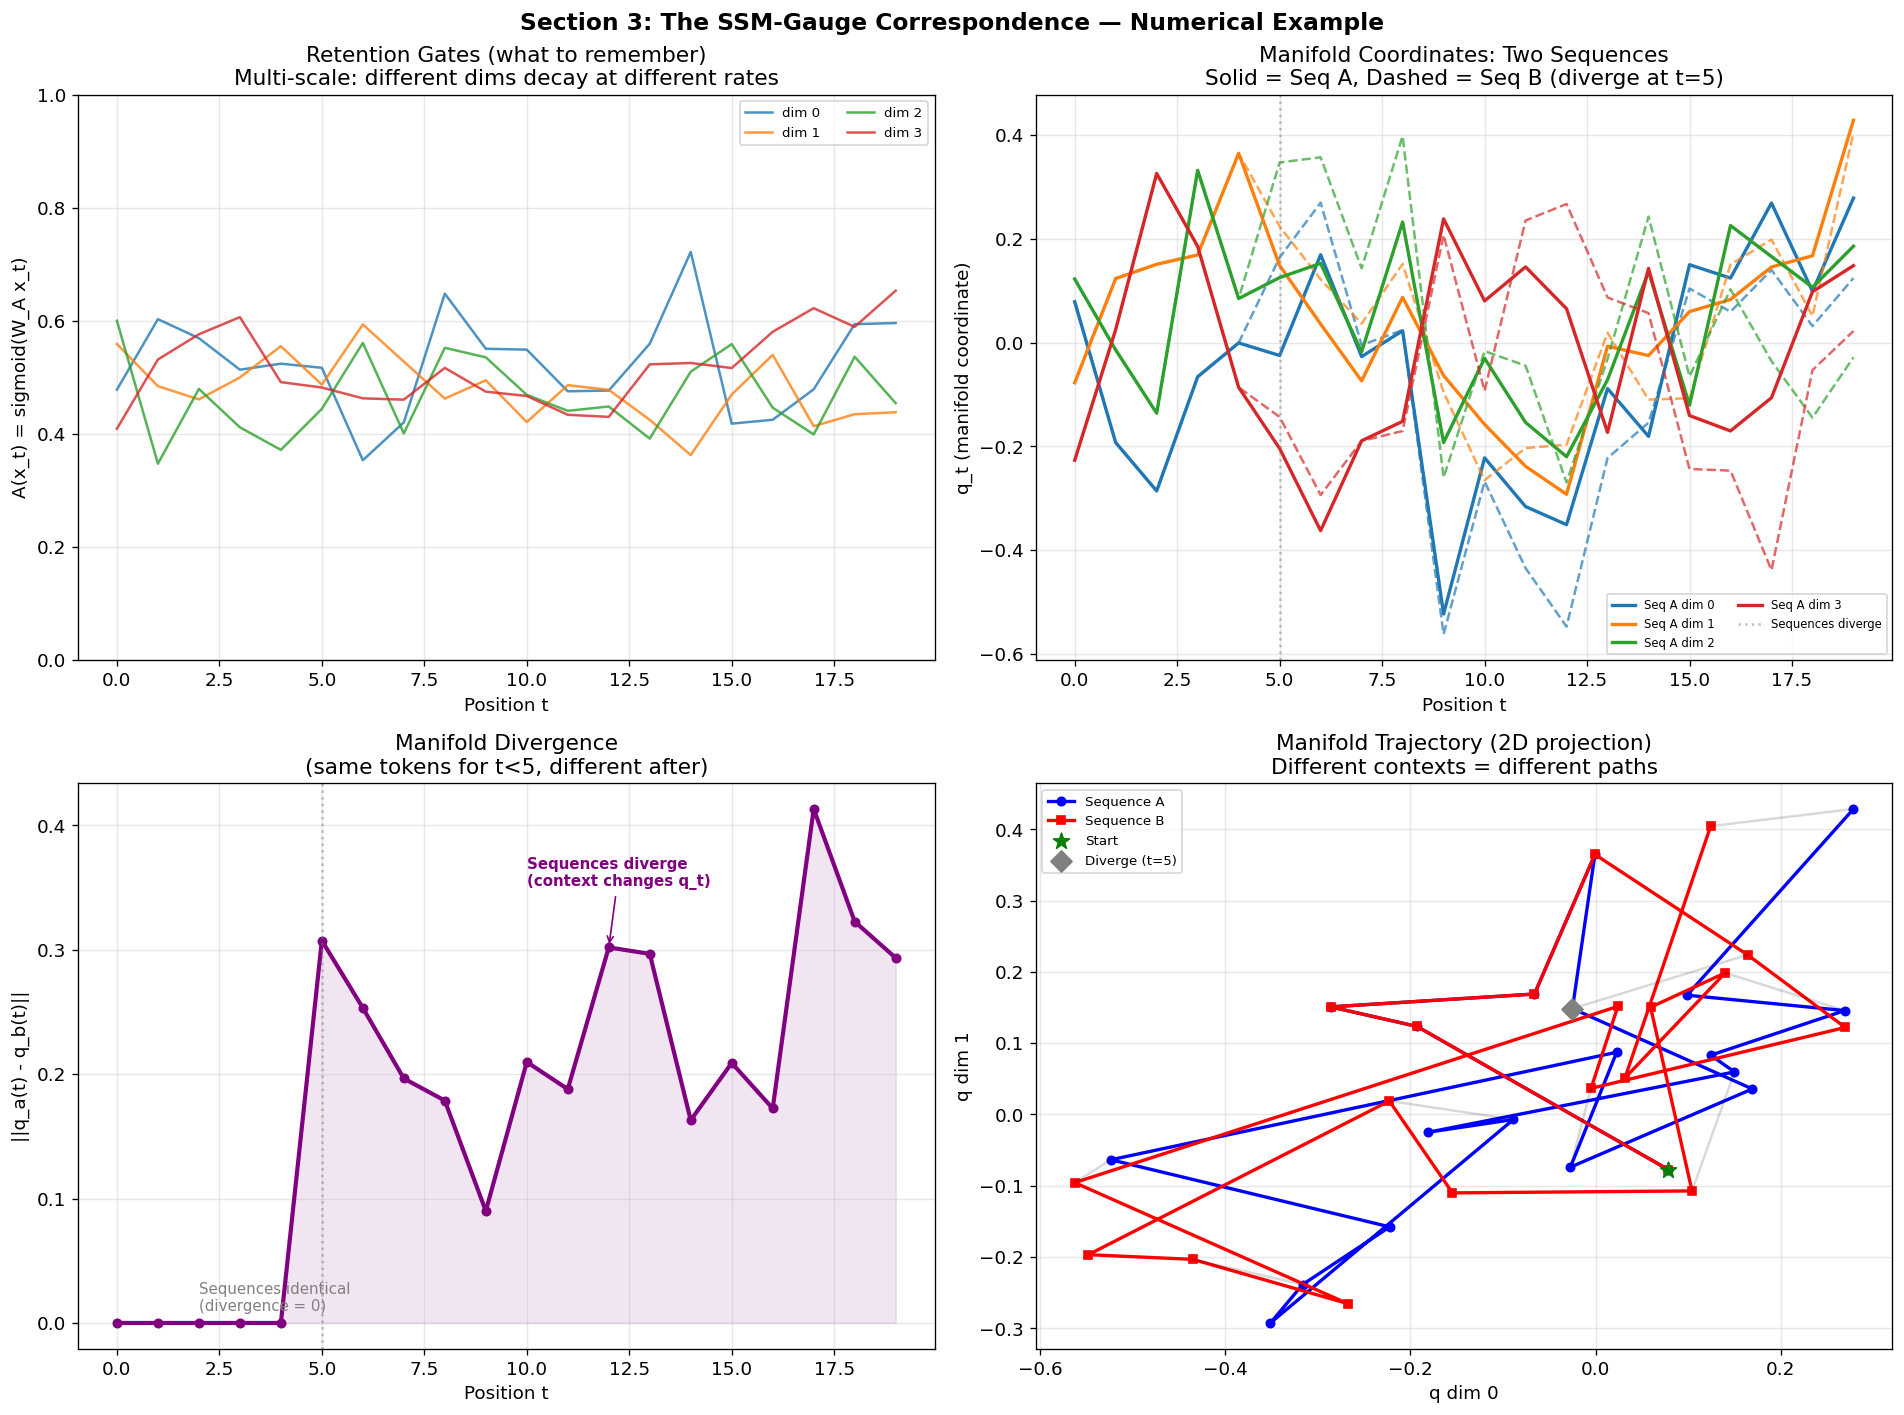

Key insight: q_t = A(x_t) * q_{t-1} + B(x_t) * psi(x_t)
  - Same tokens (t<5) produce identical q_t
  - Different tokens (t>=5) produce diverging q_t
  - The divergence persists and grows (holonomy)
  - This IS the Wilson line accumulation from gauge theory


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

T = 20
d_manifold = 4
np.random.seed(42)

# Simulate two different token sequences
tokens_a = np.random.randn(T, 8) * 0.5
tokens_b = tokens_a.copy()
tokens_b[5:] += np.random.randn(T - 5, 8) * 0.3  # diverge after position 5

def simulate_ssm(tokens, d_m, W_A, W_B, W_psi):
    """Simulate the SSM recurrence q_t = A_t * q_{t-1} + B_t * psi_t."""
    T = tokens.shape[0]
    q = np.zeros((T, d_m))
    A_vals = np.zeros((T, d_m))
    B_vals = np.zeros((T, d_m))

    for t in range(T):
        A_t = 1.0 / (1.0 + np.exp(-(tokens[t] @ W_A)))  # sigmoid
        B_t = 1.0 / (1.0 + np.exp(-(tokens[t] @ W_B)))
        psi_t = tokens[t] @ W_psi
        A_vals[t] = A_t
        B_vals[t] = B_t

        if t == 0:
            q[t] = B_t * psi_t
        else:
            q[t] = A_t * q[t-1] + B_t * psi_t
    return q, A_vals, B_vals

W_A = np.random.randn(8, d_manifold) * 0.3
W_B = np.random.randn(8, d_manifold) * 0.3
W_psi = np.random.randn(8, d_manifold) * 0.3

q_a, A_a, B_a = simulate_ssm(tokens_a, d_manifold, W_A, W_B, W_psi)
q_b, A_b, B_b = simulate_ssm(tokens_b, d_manifold, W_A, W_B, W_psi)

# Panel 1: Retention gates A(x_t) across manifold dimensions
ax = axes[0, 0]
for d in range(d_manifold):
    ax.plot(A_a[:, d], label=f'dim {d}', alpha=0.8)
ax.set_xlabel('Position t')
ax.set_ylabel('A(x_t) = sigmoid(W_A x_t)')
ax.set_title('Retention Gates (what to remember)\nMulti-scale: different dims decay at different rates')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Panel 2: Manifold coordinates q_t for both sequences
ax = axes[0, 1]
for d in range(d_manifold):
    ax.plot(q_a[:, d], '-', color=f'C{d}', lw=2, label=f'Seq A dim {d}')
    ax.plot(q_b[:, d], '--', color=f'C{d}', lw=1.5, alpha=0.7)
ax.axvline(x=5, color='gray', linestyle=':', alpha=0.5, label='Sequences diverge')
ax.set_xlabel('Position t')
ax.set_ylabel('q_t (manifold coordinate)')
ax.set_title('Manifold Coordinates: Two Sequences\nSolid = Seq A, Dashed = Seq B (diverge at t=5)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 3: Divergence ||q_a - q_b|| over positions
ax = axes[1, 0]
divergence = np.linalg.norm(q_a - q_b, axis=1)
ax.plot(divergence, 'purple', lw=2.5, marker='o', ms=5)
ax.axvline(x=5, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(range(T), 0, divergence, alpha=0.1, color='purple')
ax.set_xlabel('Position t')
ax.set_ylabel('||q_a(t) - q_b(t)||')
ax.set_title('Manifold Divergence\n(same tokens for t<5, different after)')
ax.grid(True, alpha=0.3)
ax.annotate('Sequences identical\n(divergence = 0)', xy=(2, 0.01), fontsize=9, color='gray')
ax.annotate('Sequences diverge\n(context changes q_t)', xy=(12, divergence[12]),
            fontsize=9, color='purple', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='purple'),
            xytext=(10, divergence.max() * 0.85))

# Panel 4: 2D projection of manifold trajectories
ax = axes[1, 1]
ax.plot(q_a[:, 0], q_a[:, 1], 'b-o', ms=5, lw=2, label='Sequence A')
ax.plot(q_b[:, 0], q_b[:, 1], 'r-s', ms=5, lw=2, label='Sequence B')

# Mark start and divergence point
ax.scatter([q_a[0, 0]], [q_a[0, 1]], c='green', s=100, zorder=5, marker='*', label='Start')
ax.scatter([q_a[5, 0]], [q_a[5, 1]], c='gray', s=80, zorder=5, marker='D', label='Diverge (t=5)')

# Connect corresponding positions
for t in range(5, T, 2):
    ax.plot([q_a[t, 0], q_b[t, 0]], [q_a[t, 1], q_b[t, 1]], 'k-', alpha=0.15)

ax.set_xlabel('q dim 0')
ax.set_ylabel('q dim 1')
ax.set_title('Manifold Trajectory (2D projection)\nDifferent contexts = different paths')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Section 3: The SSM-Gauge Correspondence — Numerical Example', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: q_t = A(x_t) * q_{t-1} + B(x_t) * psi(x_t)")
print("  - Same tokens (t<5) produce identical q_t")
print("  - Different tokens (t>=5) produce diverging q_t")
print("  - The divergence persists and grows (holonomy)")
print("  - This IS the Wilson line accumulation from gauge theory")

## 4. Hopfield Energy Landscapes — Context-Dependent Attractors

### The Modern Hopfield Energy

At each manifold coordinate q_t, the memory bank provides a set of attractor
atoms M_{q_t} = {m_1, m_2, ..., m_k}. The Hopfield energy landscape is:

    E_q(x; M_q) = -(1/beta) * log( sum_j exp(beta * x^T m_j) )

The gradient of this energy is:

    -grad_x E_q = -sum_j softmax(beta * x^T m_j) * m_j

This is mathematically identical to an **attention operation** — the softmax
weights the memory atoms by their similarity to x, and the gradient points toward
the weighted centroid. Iterating this gradient descent IS iterative attention refinement.

### The Critical v10.1 Claim

In v1-v9, M_q was parameterized by a positional embedding. The energy landscape
was the same at position 5 regardless of what tokens came before. The Hopfield
gradient pulled toward the same attractors for "ROMEO" and "the end."

In v10.1, M_{q_t} depends on the contextual manifold coordinate. Different
histories produce different attractor landscapes. The word "bank" after "river"
settles in a different basin than "bank" after "financial."

**The context is not a force applied to the settling token. The context IS the landscape.**

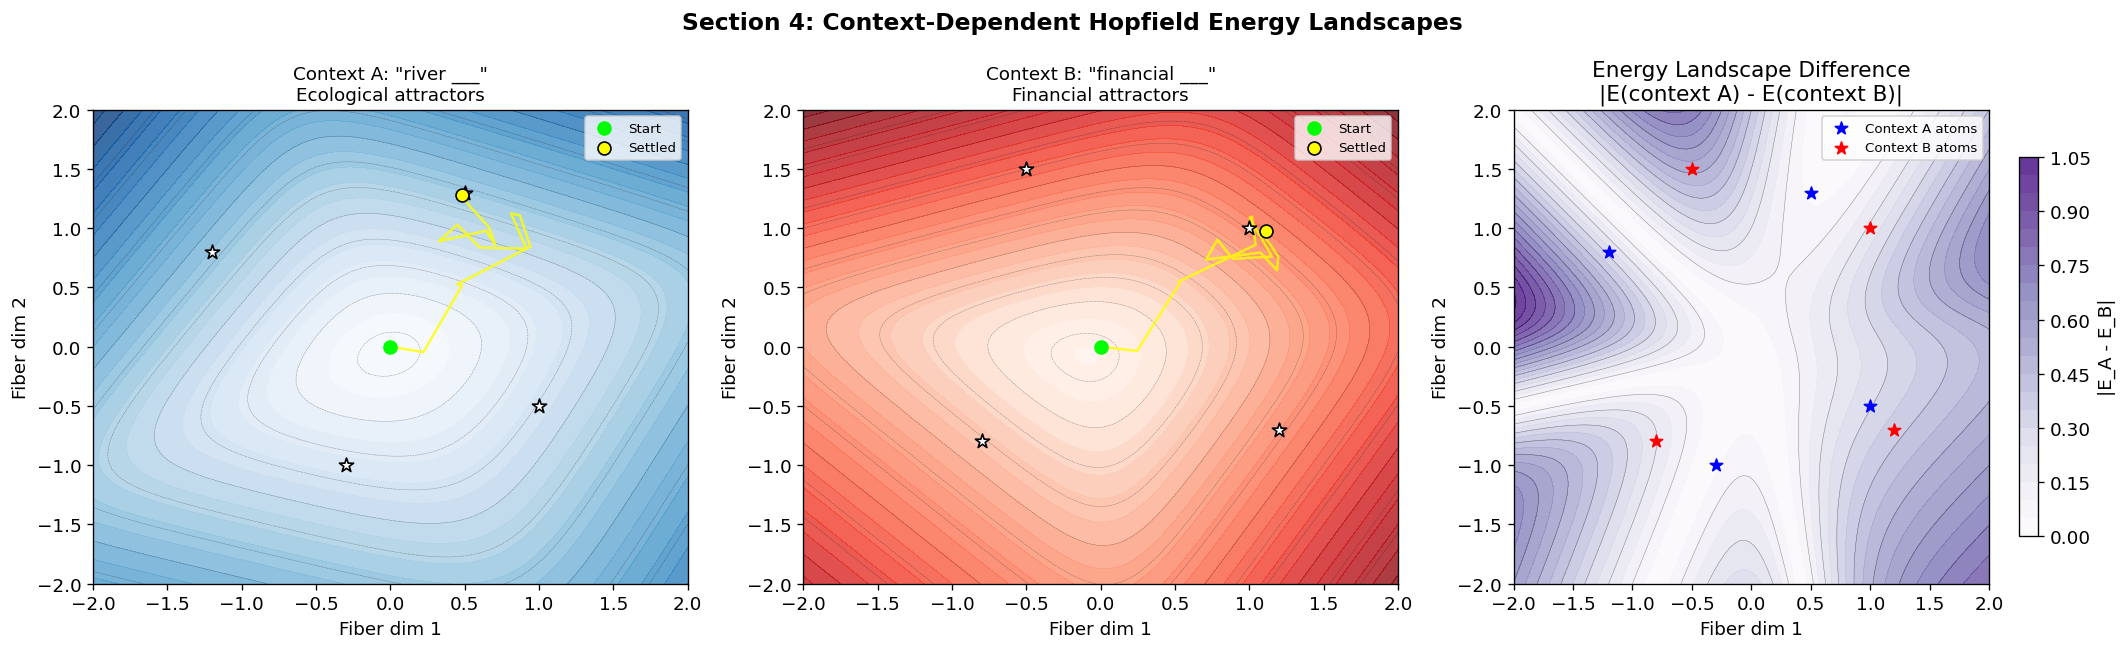

Stars = memory bank atoms (attractors)
Yellow path = Langevin settling trajectory
Same starting point, DIFFERENT landscapes -> DIFFERENT settled states
This is the core v10.1 claim: context shapes the landscape, not the forces.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 2D Hopfield energy landscape with different attractor configurations

def hopfield_energy(x, y, atoms, beta=3.0):
    """E(x) = -(1/beta) * log(sum_j exp(beta * [x,y]^T m_j))"""
    xy = np.stack([x, y], axis=-1)
    sims = np.tensordot(xy, atoms, axes=([-1], [-1]))
    return -(1.0/beta) * np.log(np.sum(np.exp(beta * sims), axis=-1) + 1e-10)

grid = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(grid, grid)

# Context A: "river bank" — ecological attractors
atoms_a = np.array([[-1.2, 0.8], [0.5, 1.3], [-0.3, -1.0], [1.0, -0.5]])
E_a = hopfield_energy(X, Y, atoms_a)

# Context B: "financial bank" — financial attractors
atoms_b = np.array([[1.0, 1.0], [-0.8, -0.8], [1.2, -0.7], [-0.5, 1.5]])
E_b = hopfield_energy(X, Y, atoms_b)

for ax, atoms, E, title, color in [
    (axes[0], atoms_a, E_a, 'Context A: "river ___"\nEcological attractors', 'Blues_r'),
    (axes[1], atoms_b, E_b, 'Context B: "financial ___"\nFinancial attractors', 'Reds_r'),
]:
    cs = ax.contourf(X, Y, E, levels=30, cmap=color, alpha=0.8)
    ax.contour(X, Y, E, levels=15, colors='k', linewidths=0.3, alpha=0.4)
    ax.scatter(atoms[:, 0], atoms[:, 1], c='white', edgecolors='black', s=80, zorder=5, marker='*')

    # Simulate Langevin trajectory
    np.random.seed(42)
    x_traj = np.array([0.0, 0.0])
    lr = 0.1
    trajectory = [x_traj.copy()]
    betas = np.linspace(1, 8, 15)

    for step, beta in enumerate(betas):
        sims = atoms @ x_traj
        weights = np.exp(beta * sims)
        weights /= weights.sum()
        grad = -weights @ atoms
        noise = np.sqrt(2 * lr / beta) * np.random.randn(2)
        x_traj = x_traj - lr * grad + noise
        trajectory.append(x_traj.copy())

    traj = np.array(trajectory)
    ax.plot(traj[:, 0], traj[:, 1], 'yellow', lw=1.5, alpha=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], c='lime', s=60, zorder=6, label='Start')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='yellow', edgecolors='black', s=60, zorder=6, label='Settled')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Fiber dim 1'); ax.set_ylabel('Fiber dim 2')
    ax.legend(fontsize=8)
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

# Panel 3: Overlay showing the landscapes are different
E_diff = np.abs(E_a - E_b)
cs = axes[2].contourf(X, Y, E_diff, levels=20, cmap='Purples', alpha=0.8)
axes[2].contour(X, Y, E_diff, levels=10, colors='k', linewidths=0.3, alpha=0.4)
axes[2].scatter(atoms_a[:, 0], atoms_a[:, 1], c='blue', s=60, marker='*', label='Context A atoms', zorder=5)
axes[2].scatter(atoms_b[:, 0], atoms_b[:, 1], c='red', s=60, marker='*', label='Context B atoms', zorder=5)
plt.colorbar(cs, ax=axes[2], shrink=0.8, label='|E_A - E_B|')
axes[2].set_title('Energy Landscape Difference\n|E(context A) - E(context B)|')
axes[2].set_xlabel('Fiber dim 1'); axes[2].set_ylabel('Fiber dim 2')
axes[2].legend(fontsize=8)
axes[2].set_xlim(-2, 2); axes[2].set_ylim(-2, 2)

plt.suptitle('Section 4: Context-Dependent Hopfield Energy Landscapes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Stars = memory bank atoms (attractors)")
print("Yellow path = Langevin settling trajectory")
print("Same starting point, DIFFERENT landscapes -> DIFFERENT settled states")
print("This is the core v10.1 claim: context shapes the landscape, not the forces.")

## 5. Curvature and Adaptive Routing

### Discrete Curvature of the Manifold Trajectory

The manifold coordinates q_0, q_1, ..., q_T trace a curve in R^{d_m}. The
**discrete curvature** at position t measures how sharply this curve bends:

    kappa_t = ||q_t - 2*q_{t-1} + q_{t-2}|| / ||q_t - q_{t-1}||^2

This is the ratio of acceleration to velocity squared — exactly the Frenet-Serret
curvature discretized on a polygonal curve.

### Semantic Interpretation

- **High curvature** = rapid context change (topic shift, speaker change, sentence boundary)
- **Low curvature** = smooth continuation (mid-word, mid-phrase)

### Curvature-Aware Memory Routing

The number of active memory atoms at position t depends on the curvature:

    k_t = k_min + floor(kappa_norm_t * (k_max - k_min))

- High curvature → more atoms → broader attractor landscape → more exploration
- Low curvature → fewer atoms → narrow landscape → decisive settling

This connects to Gurnee et al.'s finding: the character count manifold in Claude
has high curvature precisely where the model needs high resolution (near line
boundaries). The place cells should be denser where the manifold curves sharply.

### Curvature-Modulated Inverse Temperature

The Langevin beta is also modulated:

    beta_effective = beta_base / (1 + alpha * kappa_t)

High curvature → lower beta → more noise → more exploration. The settling process
becomes geometry-aware: cautious in regions of rapid change, decisive in smooth regions.

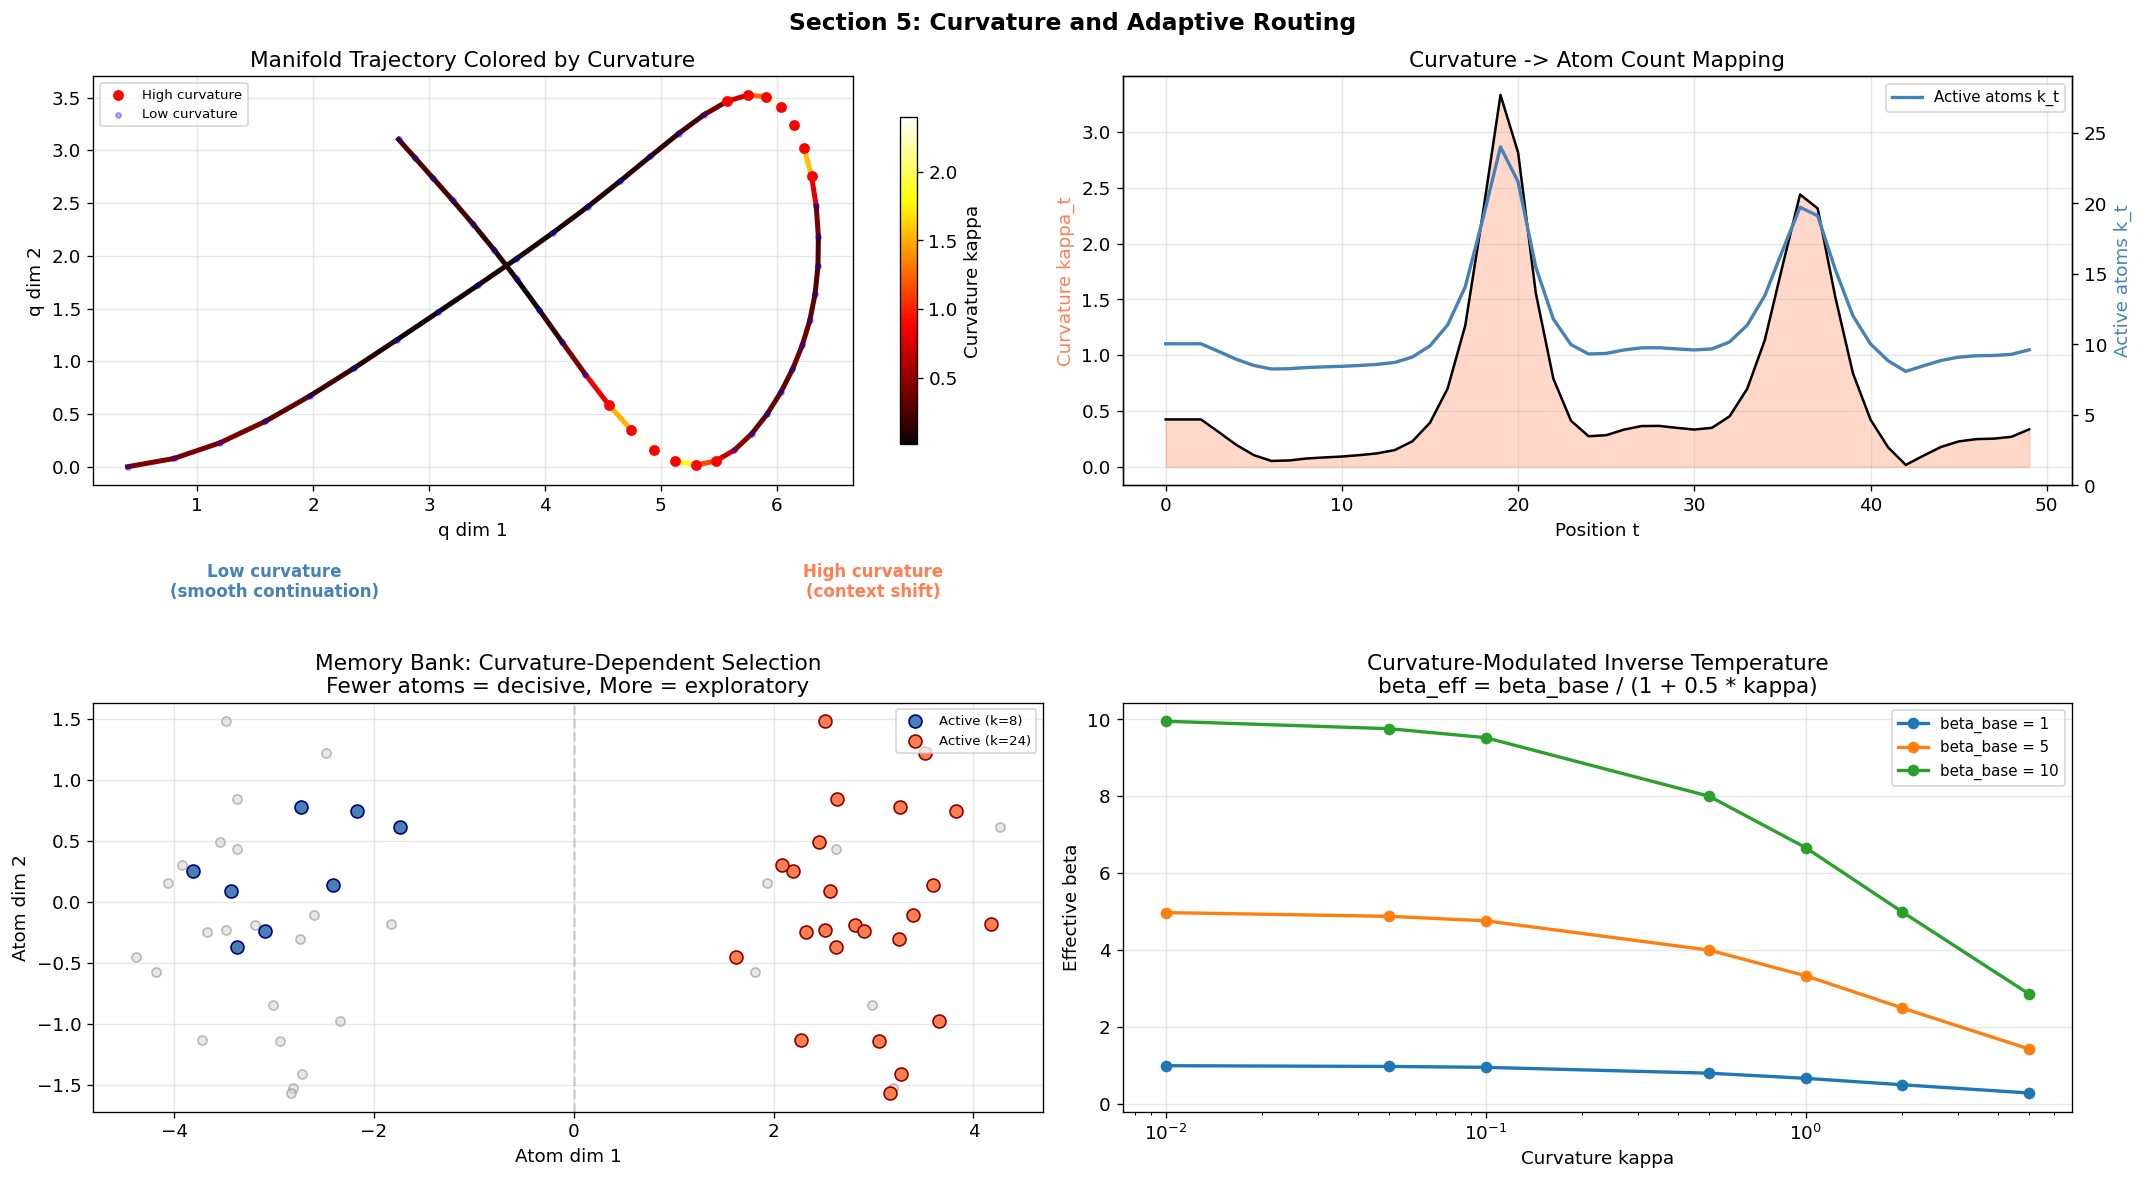

In [6]:
fig = plt.figure(figsize=(18, 10))

# --- Panel 1: Manifold curve with curvature coloring ---
ax1 = fig.add_subplot(221)

T = 50
t = np.linspace(0, 4 * np.pi, T)
# A curve with varying curvature
q_x = np.cumsum(0.3 * np.cos(t * 0.3) + 0.1)
q_y = np.cumsum(0.3 * np.sin(t * 0.7) + 0.05 * np.sin(t * 2.0))

# Compute discrete curvature
vel = np.diff(np.column_stack([q_x, q_y]), axis=0)
accel = np.diff(vel, axis=0)
accel_norm = np.linalg.norm(accel, axis=1)
vel_norm_sq = np.linalg.norm(vel[:-1], axis=1) ** 2 + 1e-10
kappa = accel_norm / vel_norm_sq

# Pad curvature to match positions
kappa_full = np.concatenate([[kappa[0], kappa[0]], kappa])

# Color the trajectory by curvature
norm = Normalize(vmin=kappa.min(), vmax=np.percentile(kappa, 95))
for i in range(T - 1):
    ax1.plot(q_x[i:i+2], q_y[i:i+2], color=cm.hot(norm(kappa_full[i])), lw=3)

sm = cm.ScalarMappable(cmap='hot', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax1, label='Curvature kappa', shrink=0.8)

# Mark high-curvature points
high_curv_mask = kappa_full > np.percentile(kappa_full, 75)
ax1.scatter(q_x[high_curv_mask], q_y[high_curv_mask], c='red', s=30, zorder=5, label='High curvature')
ax1.scatter(q_x[~high_curv_mask], q_y[~high_curv_mask], c='blue', s=10, zorder=4, alpha=0.3, label='Low curvature')

ax1.set_xlabel('q dim 1')
ax1.set_ylabel('q dim 2')
ax1.set_title('Manifold Trajectory Colored by Curvature')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Curvature over position ---
ax2 = fig.add_subplot(222)
ax2.plot(kappa_full, 'k-', lw=1.5)
ax2.fill_between(range(T), 0, kappa_full, alpha=0.3, color='coral')

# Thresholds for k_min, k_max regions
k_min, k_max = 8, 24
kappa_norm = kappa_full / (kappa_full.max() + 1e-8)
k_active = k_min + kappa_norm * (k_max - k_min)

ax2_twin = ax2.twinx()
ax2_twin.plot(k_active, 'steelblue', lw=2, label='Active atoms k_t')
ax2_twin.set_ylabel('Active atoms k_t', color='steelblue')
ax2_twin.set_ylim(0, k_max + 5)

ax2.set_xlabel('Position t')
ax2.set_ylabel('Curvature kappa_t', color='coral')
ax2.set_title('Curvature -> Atom Count Mapping')
ax2.grid(True, alpha=0.3)
ax2_twin.legend(fontsize=9, loc='upper right')

# --- Panel 3: Memory bank visualization at low vs high curvature ---
ax3 = fig.add_subplot(223)

np.random.seed(42)
n_atoms = 30
all_atoms = np.random.randn(n_atoms, 2) * 0.8

# Low curvature: fewer atoms active (k=8)
active_low = np.random.choice(n_atoms, 8, replace=False)
# High curvature: more atoms active (k=24)
active_high = np.random.choice(n_atoms, 24, replace=False)

inactive_mask_low = np.ones(n_atoms, dtype=bool)
inactive_mask_low[active_low] = False
inactive_mask_high = np.ones(n_atoms, dtype=bool)
inactive_mask_high[active_high] = False

ax3.scatter(all_atoms[inactive_mask_low, 0] - 3, all_atoms[inactive_mask_low, 1],
            c='lightgray', s=30, alpha=0.5, edgecolors='gray')
ax3.scatter(all_atoms[active_low, 0] - 3, all_atoms[active_low, 1],
            c='steelblue', s=60, edgecolors='navy', zorder=5, label=f'Active (k={len(active_low)})')

ax3.scatter(all_atoms[inactive_mask_high, 0] + 3, all_atoms[inactive_mask_high, 1],
            c='lightgray', s=30, alpha=0.5, edgecolors='gray')
ax3.scatter(all_atoms[active_high, 0] + 3, all_atoms[active_high, 1],
            c='coral', s=60, edgecolors='darkred', zorder=5, label=f'Active (k={len(active_high)})')

ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax3.text(-3, 2.5, 'Low curvature\n(smooth continuation)', ha='center', fontsize=10, fontweight='bold', color='steelblue')
ax3.text(3, 2.5, 'High curvature\n(context shift)', ha='center', fontsize=10, fontweight='bold', color='coral')

ax3.set_xlabel('Atom dim 1')
ax3.set_ylabel('Atom dim 2')
ax3.set_title('Memory Bank: Curvature-Dependent Selection\nFewer atoms = decisive, More = exploratory')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Beta modulation ---
ax4 = fig.add_subplot(224)

beta_base_range = np.linspace(1, 10, 6)  # annealing schedule
kappa_example = np.array([0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0])
alpha_scale = 0.5

for beta_base in [1.0, 5.0, 10.0]:
    beta_eff = beta_base / (1.0 + alpha_scale * kappa_example)
    ax4.plot(kappa_example, beta_eff, 'o-', lw=2, label=f'beta_base = {beta_base:.0f}')

ax4.set_xlabel('Curvature kappa')
ax4.set_ylabel('Effective beta')
ax4.set_title('Curvature-Modulated Inverse Temperature\nbeta_eff = beta_base / (1 + 0.5 * kappa)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xscale('log')

plt.suptitle('Section 5: Curvature and Adaptive Routing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. The Pure Langevin SDE — Thermodynamic Settling

### The Stochastic Differential Equation

Each token settles on the contextual energy landscape via annealed Langevin dynamics:

    dx = -eta * grad_x E_q(x; M_{q_t}) * dt + sqrt(2*eta/beta_t) * dW

where:
- `grad_x E_q` is the Hopfield gradient (the ONLY force in v10.1)
- `eta` is the step size
- `beta_t` is the inverse temperature (annealed from low to high)
- `dW` is Brownian noise

### Annealing Schedule

The inverse temperature beta_t increases linearly from beta_init to beta_final:

    beta_t = beta_init + t/T * (beta_final - beta_init)

- **Early steps** (low beta): high noise, broad exploration of the energy landscape
- **Late steps** (high beta): low noise, precise convergence to nearest attractor

This is **simulated annealing** — the settling process first explores globally, then
commits locally. The noise schedule is a thermodynamic protocol.

### Proximal Sparsity (Axiom 5)

On the final Langevin step only, soft-thresholding enforces structural sparsity:

    x_sparse = sign(x) * max(|x| - lambda * eta, 0)

This produces the sparse activation patterns that are the architecture's signature:
each subbundle has only a few active dimensions, creating the quantifiable
"contextual fingerprint" described in the PhD exploration.

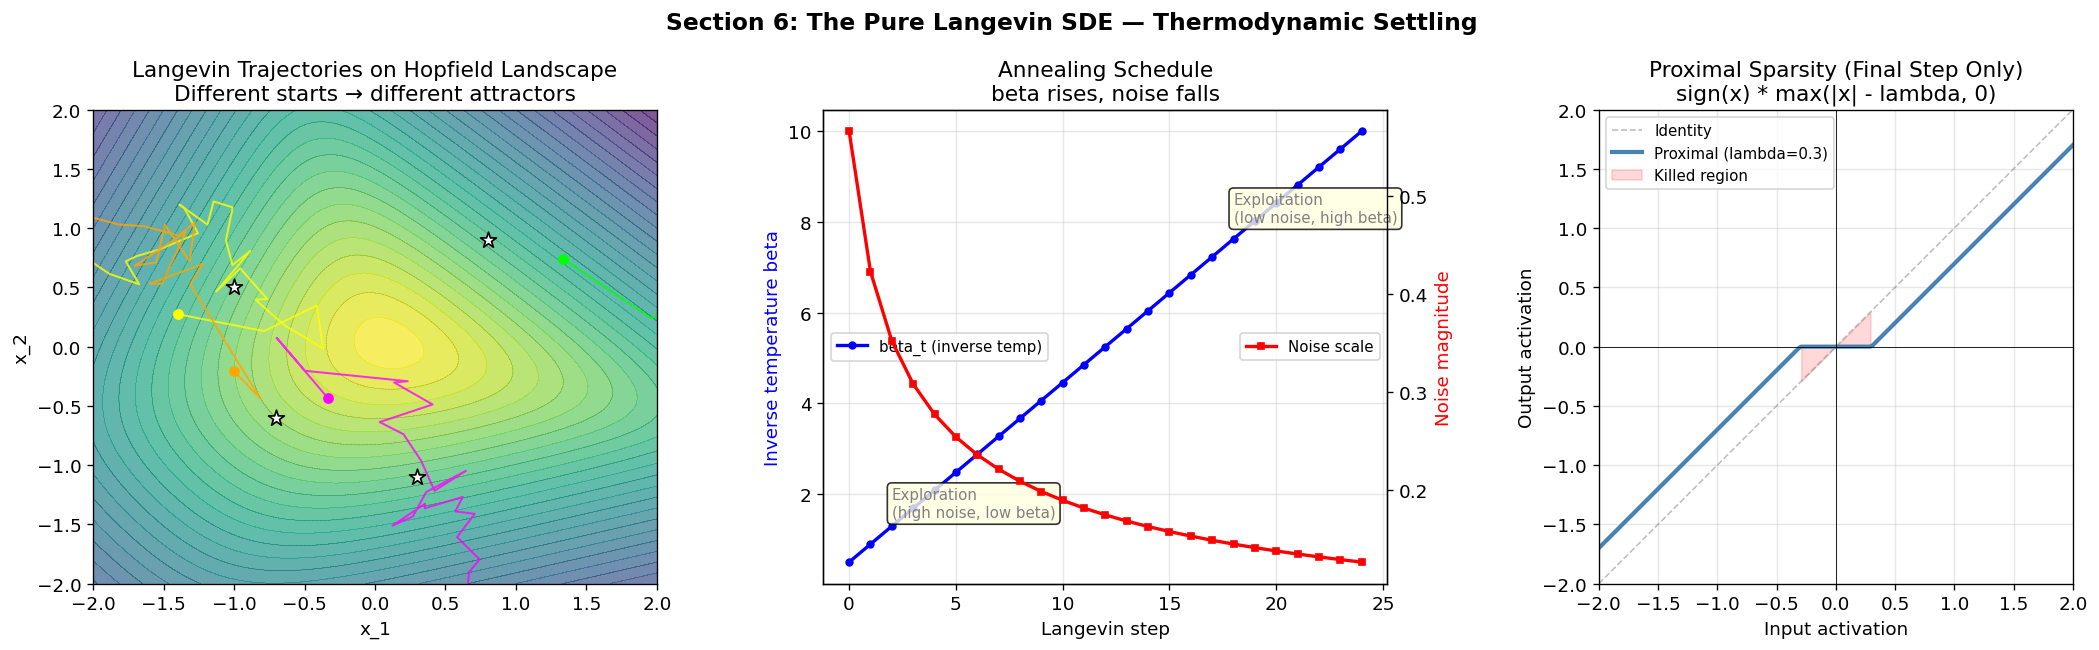

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel 1: Langevin trajectory on energy landscape ---
ax = axes[0]

np.random.seed(42)
atoms = np.array([[-1.0, 0.5], [0.8, 0.9], [0.3, -1.1], [-0.7, -0.6]])

grid = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(grid, grid)

def hopfield_energy(x, y, atoms, beta=3.0):
    xy = np.stack([x, y], axis=-1)
    sims = np.tensordot(xy, atoms, axes=([-1], [-1]))
    return -(1.0/beta) * np.log(np.sum(np.exp(beta * sims), axis=-1) + 1e-10)

E = hopfield_energy(X, Y, atoms)
ax.contourf(X, Y, E, levels=30, cmap='viridis', alpha=0.7)
ax.contour(X, Y, E, levels=15, colors='k', linewidths=0.3, alpha=0.3)
ax.scatter(atoms[:, 0], atoms[:, 1], c='white', edgecolors='black', s=100, marker='*', zorder=5)

# Simulate annealing: multiple trajectories
n_trajs = 5
lr = 0.08
n_steps = 25
betas = np.linspace(0.5, 10, n_steps)
traj_colors = ['yellow', 'cyan', 'lime', 'orange', 'magenta']

for traj_i in range(n_trajs):
    np.random.seed(100 + traj_i)
    x_t = np.random.randn(2) * 0.8
    trajectory = [x_t.copy()]

    for step, beta in enumerate(betas):
        sims = atoms @ x_t
        weights = np.exp(beta * sims)
        weights /= weights.sum()
        grad = -weights @ atoms
        noise = np.sqrt(2 * lr / beta) * np.random.randn(2)
        x_t = x_t - lr * grad + noise
        trajectory.append(x_t.copy())

    traj = np.array(trajectory)
    ax.plot(traj[:, 0], traj[:, 1], traj_colors[traj_i], lw=1.2, alpha=0.8)
    ax.scatter(traj[0, 0], traj[0, 1], c=traj_colors[traj_i], s=30, marker='o', zorder=4)
    ax.scatter(traj[-1, 0], traj[-1, 1], c=traj_colors[traj_i], edgecolors='black', s=50, marker='D', zorder=4)

ax.set_title('Langevin Trajectories on Hopfield Landscape\nDifferent starts → different attractors')
ax.set_xlabel('x_1'); ax.set_ylabel('x_2')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

# --- Panel 2: Annealing schedule ---
ax = axes[1]

steps = np.arange(n_steps)
beta_schedule = np.linspace(0.5, 10, n_steps)
noise_schedule = np.sqrt(2 * lr / beta_schedule)

ax.plot(steps, beta_schedule, 'b-o', ms=4, lw=2, label='beta_t (inverse temp)')
ax_twin = ax.twinx()
ax_twin.plot(steps, noise_schedule, 'r-s', ms=4, lw=2, label='Noise scale')
ax_twin.set_ylabel('Noise magnitude', color='red')

ax.set_xlabel('Langevin step')
ax.set_ylabel('Inverse temperature beta', color='blue')
ax.set_title('Annealing Schedule\nbeta rises, noise falls')
ax.legend(loc='center left', fontsize=9)
ax_twin.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)

# Annotations
ax.annotate('Exploration\n(high noise, low beta)', xy=(2, 1.5), fontsize=9, color='gray',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.annotate('Exploitation\n(low noise, high beta)', xy=(18, 8), fontsize=9, color='gray',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Panel 3: Proximal sparsity ---
ax = axes[2]

x_dense = np.linspace(-2, 2, 200)
lam = 0.3
x_sparse = np.sign(x_dense) * np.maximum(np.abs(x_dense) - lam, 0)

ax.plot(x_dense, x_dense, 'gray', linestyle='--', lw=1, alpha=0.5, label='Identity')
ax.plot(x_dense, x_sparse, 'steelblue', lw=2.5, label=f'Proximal (lambda={lam})')
ax.axhline(y=0, color='k', lw=0.5)
ax.axvline(x=0, color='k', lw=0.5)

ax.fill_between(x_dense, 0, x_dense, where=(np.abs(x_dense) < lam),
                alpha=0.15, color='red', label='Killed region')

ax.set_xlabel('Input activation')
ax.set_ylabel('Output activation')
ax.set_title('Proximal Sparsity (Final Step Only)\nsign(x) * max(|x| - lambda, 0)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')

plt.suptitle('Section 6: The Pure Langevin SDE — Thermodynamic Settling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Diagnostic Audit — What the v10.1 Training Metrics Reveal

### The Observed Metrics

```
Step     0 | Val BPC: 8.03 | Val Acc:  0.2% | kappa: 0.19
Step   200 | Val BPC: 3.69 | Val Acc: 27.7% | kappa: 0.06
Step   400 | Val BPC: 3.53 | Val Acc: 29.5% | kappa: 0.05
Step   600 | Val BPC: 3.48 | Val Acc: 30.1% | kappa: 0.04
Step   800 | Val BPC: 3.45 | Val Acc: 30.8% | kappa: 0.03
Step  1000 | Val BPC: 3.46 | Val Acc: 30.3% | kappa: 0.03
Step  1200 | Val BPC: 3.47 | Val Acc: 30.0% | kappa: 0.03
```

### Three Critical Observations

**1. The manifold is going FLAT (kappa: 0.19 → 0.03)**

The curvature is collapsing by 6x during training. This means the manifold trajectory
is straightening out — the contextual coordinates are becoming a near-linear function
of position. The architecture is *learning to undo its own contextual structure*
and reverting toward a flat positional embedding.

Why? The gradient through the curvature-aware routing creates an incentive to minimize
curvature. Lower curvature → fewer active atoms (k approaches k_min) → simpler
Hopfield landscape → easier for the gradient to optimize. The model finds it
cheaper to flatten the manifold than to learn to use it.

**2. Performance plateaus at 30% (vs v9's 45%)**

Removing forces 2-4 (causal convolution, lateral inhibition, attention) cost 15
percentage points. The pure SDE hypothesis — that context alone suffices — is
not validated at this scale. The cross-position forces were doing real work that
the contextual manifold alone cannot replace.

**3. The contextual manifold works (kappa > 0) but is too weak**

The manifold IS contextual (kappa starts at 0.19, not 0). The parallel scan IS
producing content-dependent coordinates. But the signal is being washed out by
optimization pressure toward flatness. The manifold needs structural support to
maintain its curvature.

### Root Cause Analysis

The fundamental issue is a **curvature collapse** feedback loop:

```
Lower curvature → fewer active atoms → simpler landscape
→ easier to optimize → gradient pushes toward even lower curvature
→ manifold flattens further → eventually reverts to ~positional embedding
```

This is the geometric analog of mode collapse in GANs — the model finds a
degenerate solution (flat manifold) that is locally optimal but globally poor.

### Potential Fixes (for v10.2)

1. **Curvature regularization**: Add a loss term that penalizes low curvature,
   `L_curv = -mean(kappa_t)`, forcing the manifold to maintain geometric structure.

2. **Minimum curvature floor**: Clamp kappa_t >= kappa_min in the routing, preventing
   the gradient from collapsing curvature to zero.

3. **Detach curvature from routing gradient**: Use `curvature.detach()` when computing
   atom counts, so the routing gradient doesn't flow back to flatten the manifold.

4. **Selective force reintroduction**: The pure SDE hypothesis may be too aggressive.
   Re-add attention (force 4) as a lightweight cross-position signal, keeping
   the contextual manifold as the primary context carrier.

5. **Curvature-weighted loss**: Weight the CE loss by curvature — high-curvature
   positions (context shifts) get higher loss weight, encouraging the model to
   invest representational capacity where the geometry is most complex.

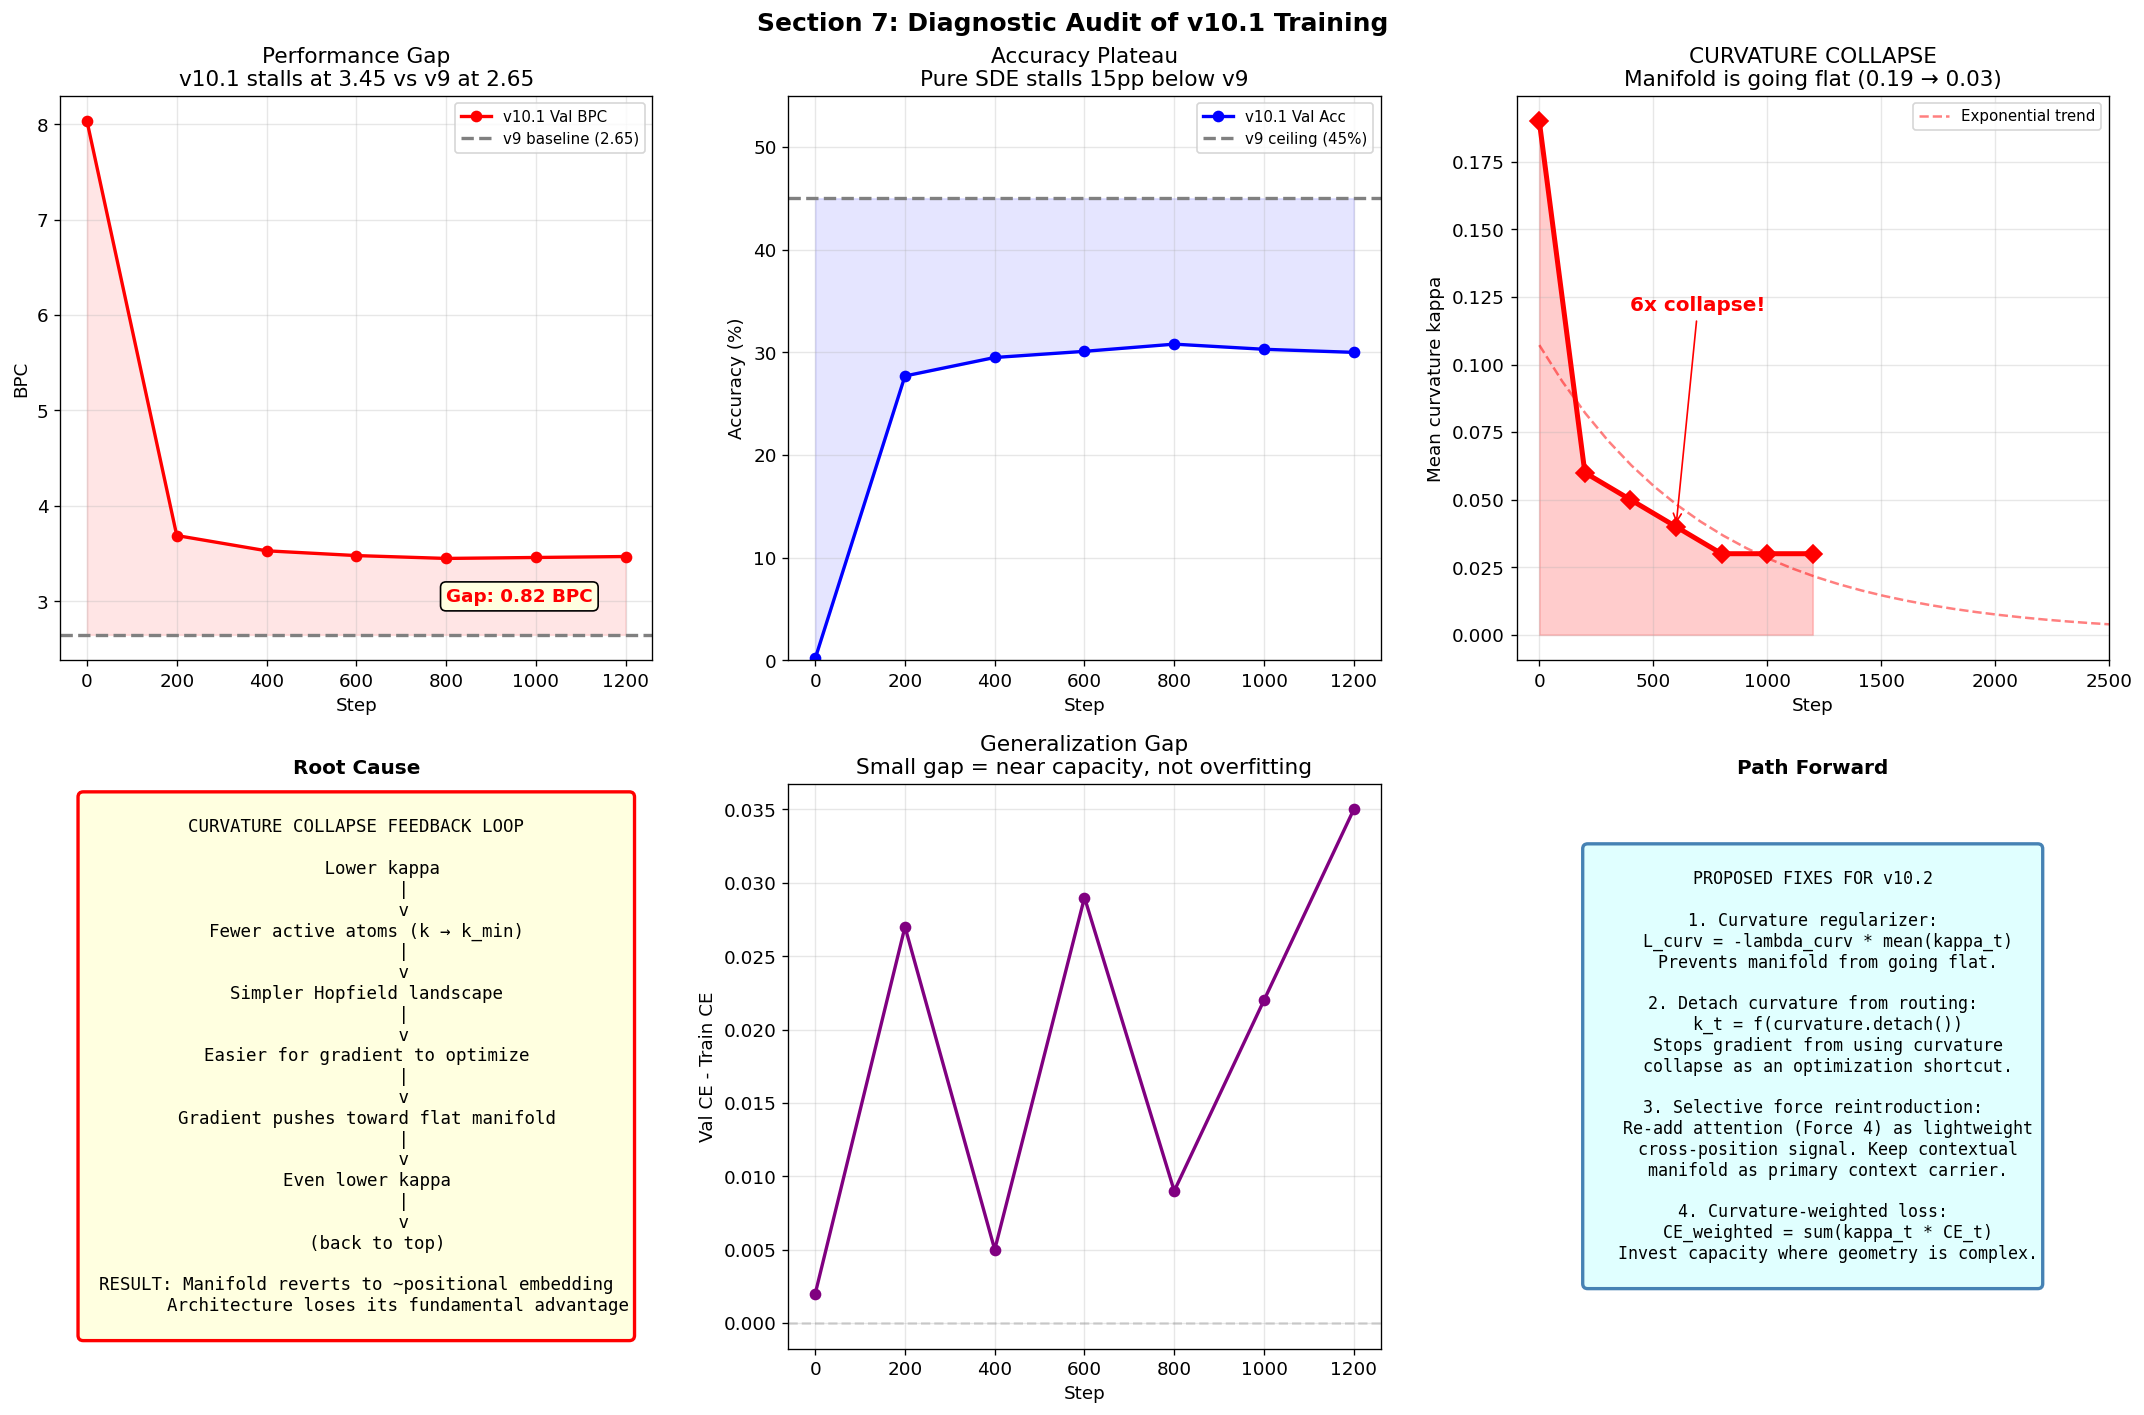

AUDIT SUMMARY
v10.1 Val BPC: 3.47  (v9: 2.65)  Gap: +0.82
v10.1 Val Acc: 30.0%  (v9: 45%)   Gap: -15.0pp
Curvature:     0.19 → 0.03  (16% of initial)

DIAGNOSIS: Curvature collapse. The optimization landscape incentivizes
           a flat manifold, defeating the contextual paradigm.

PROGNOSIS: The contextual manifold IS working (kappa > 0 initially)
           but needs structural support to maintain its geometry.
           Pure SDE (no cross-position forces) is too aggressive a
           simplification at this parameter scale.


In [ ]:
fig = plt.figure(figsize=(18, 12))

# Observed training metrics
steps =   [0,    200,  400,  600,  800,  1000, 1200]
val_bpc = [8.03, 3.69, 3.53, 3.48, 3.45, 3.46, 3.47]
val_acc = [0.2,  27.7, 29.5, 30.1, 30.8, 30.3, 30.0]
kappa =   [0.19, 0.06, 0.05, 0.04, 0.03, 0.03, 0.03]
train_ce = [5.563, 2.531, 2.444, 2.386, 2.383, 2.375, 2.371]
val_ce =   [5.565, 2.558, 2.449, 2.415, 2.392, 2.397, 2.406]

# --- Panel 1: BPC with v9 baseline ---
ax1 = fig.add_subplot(231)
ax1.plot(steps, val_bpc, 'r-o', lw=2, ms=6, label='v10.1 Val BPC')
ax1.axhline(y=2.65, color='gray', linestyle='--', lw=2, label='v9 baseline (2.65)')
ax1.fill_between(steps, val_bpc, 2.65, alpha=0.1, color='red')
ax1.set_xlabel('Step'); ax1.set_ylabel('BPC')
ax1.set_title('Performance Gap\nv10.1 stalls at 3.45 vs v9 at 2.65')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.annotate(f'Gap: {val_bpc[-1] - 2.65:.2f} BPC', xy=(800, 3.0),
             fontsize=11, fontweight='bold', color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

# --- Panel 2: Accuracy plateau ---
ax2 = fig.add_subplot(232)
ax2.plot(steps, val_acc, 'b-o', lw=2, ms=6, label='v10.1 Val Acc')
ax2.axhline(y=45, color='gray', linestyle='--', lw=2, label='v9 ceiling (45%)')
ax2.fill_between(steps, val_acc, 45, alpha=0.1, color='blue')
ax2.set_xlabel('Step'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Plateau\nPure SDE stalls 15pp below v9')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 55)

# --- Panel 3: KAPPA COLLAPSE (the critical finding) ---
ax3 = fig.add_subplot(233)
ax3.plot(steps, kappa, 'red', lw=3, marker='D', ms=8)
ax3.fill_between(steps, 0, kappa, alpha=0.2, color='red')
ax3.set_xlabel('Step'); ax3.set_ylabel('Mean curvature kappa')
ax3.set_title('CURVATURE COLLAPSE\nManifold is going flat (0.19 → 0.03)')
ax3.grid(True, alpha=0.3)
ax3.annotate('6x collapse!', xy=(600, 0.04), fontsize=12, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red'),
             xytext=(400, 0.12))

# Exponential fit
from numpy.polynomial import polynomial as P
log_kappa = np.log(np.array(kappa) + 1e-8)
# Simple linear fit on log(kappa) vs step
coeffs = np.polyfit(steps, log_kappa, 1)
fit_steps = np.linspace(0, 10000, 100)
fit_kappa = np.exp(np.polyval(coeffs, fit_steps))
ax3.plot(fit_steps, fit_kappa, 'r--', alpha=0.5, label='Exponential trend')
ax3.set_xlim(-100, 2500)
ax3.legend(fontsize=9)

# --- Panel 4: Curvature collapse feedback loop ---
ax4 = fig.add_subplot(234)
ax4.axis('off')

loop_text = """
CURVATURE COLLAPSE FEEDBACK LOOP

     Lower kappa
         |
         v
  Fewer active atoms (k → k_min)
         |
         v
  Simpler Hopfield landscape
         |
         v
  Easier for gradient to optimize
         |
         v
  Gradient pushes toward flat manifold
         |
         v
  Even lower kappa
         |
         v
    (back to top)

RESULT: Manifold reverts to ~positional embedding
        Architecture loses its fundamental advantage
"""
ax4.text(0.5, 0.5, loop_text, transform=ax4.transAxes, fontsize=10.5,
         ha='center', va='center', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red', lw=2))
ax4.set_title('Root Cause', fontsize=12, fontweight='bold')

# --- Panel 5: Generalization gap ---
ax5 = fig.add_subplot(235)
gap = [v - t for v, t in zip(val_ce, train_ce)]
ax5.plot(steps, gap, 'purple', lw=2, marker='o', ms=6)
ax5.set_xlabel('Step'); ax5.set_ylabel('Val CE - Train CE')
ax5.set_title('Generalization Gap\nSmall gap = near capacity, not overfitting')
ax5.grid(True, alpha=0.3)
ax5.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# --- Panel 6: What to do next ---
ax6 = fig.add_subplot(236)
ax6.axis('off')

fixes = """
PROPOSED FIXES FOR v10.2

1. Curvature regularizer:
   L_curv = -lambda_curv * mean(kappa_t)
   Prevents manifold from going flat.

2. Detach curvature from routing:
   k_t = f(curvature.detach())
   Stops gradient from using curvature
   collapse as an optimization shortcut.

3. Selective force reintroduction:
   Re-add attention (Force 4) as lightweight
   cross-position signal. Keep contextual
   manifold as primary context carrier.

4. Curvature-weighted loss:
   CE_weighted = sum(kappa_t * CE_t)
   Invest capacity where geometry is complex.
"""
ax6.text(0.5, 0.5, fixes, transform=ax6.transAxes, fontsize=10,
         ha='center', va='center', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightcyan', edgecolor='steelblue', lw=2))
ax6.set_title('Path Forward', fontsize=12, fontweight='bold')

plt.suptitle('Section 7: Diagnostic Audit of v10.1 Training', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)
print(f"v10.1 Val BPC: {val_bpc[-1]:.2f}  (v9: 2.65)  Gap: +{val_bpc[-1]-2.65:.2f}")
print(f"v10.1 Val Acc: {val_acc[-1]:.1f}%  (v9: 45%)   Gap: -{45-val_acc[-1]:.1f}pp")
print(f"Curvature:     {kappa[0]:.2f} → {kappa[-1]:.2f}  ({kappa[-1]/kappa[0]:.0%} of initial)")
print()
print("DIAGNOSIS: Curvature collapse. The optimization landscape incentivizes")
print("           a flat manifold, defeating the contextual paradigm.")
print()
print("PROGNOSIS: The contextual manifold IS working (kappa > 0 initially)")
print("           but needs structural support to maintain its geometry.")
print("           Pure SDE (no cross-position forces) is too aggressive a")
print("           simplification at this parameter scale.")

## 8. The Life of a Training Step — Forward Propagation to Weight Update

This section traces the complete computational story of a single training step:
how data flows forward through the architecture, how loss is computed, how
gradients propagate backward, and what each parameter group actually learns.

Every equation is written for hand transcription.

---

### 8.1 Forward Pass — Stage 1: Token Embedding and Sparsification

**Input:** Token IDs $\,\mathbf{t} \in \mathbb{Z}^{B \times T}$, where $B$ is batch size, $T$ is sequence length.

**Step 1a — Dense embedding lookup:**

$$e_t = W_{\text{emb}}[\mathbf{t}_t] \in \mathbb{R}^{D}, \qquad W_{\text{emb}} \in \mathbb{R}^{V \times D}$$

where $V = 256$ (ASCII vocab), $D = 256$ (fiber dim).

**Step 1b — Per-subbundle top-$s$ sparsification:**

Split $e_t$ into $K = 8$ chunks of dimension $d = D/K = 32$:

$$e_t = [e_t^{(1)};\; e_t^{(2)};\; \ldots;\; e_t^{(K)}], \qquad e_t^{(k)} \in \mathbb{R}^d$$

For each subbundle $k$, keep only the $s = d/4 = 8$ largest-magnitude entries:

$$S_t^{(k)} = \text{argtop-}s\!\left(|e_t^{(k)}|\right), \qquad \hat{e}_t^{(k)} = e_t^{(k)} \odot \mathbf{1}_{S_t^{(k)}}$$

where $\mathbf{1}_{S_t^{(k)}}$ is the binary mask with 1s at the top-$s$ indices. The sparse embedding is:

$$x_t = [\hat{e}_t^{(1)};\; \hat{e}_t^{(2)};\; \ldots;\; \hat{e}_t^{(K)}] \in \mathbb{R}^D$$

**Gradient note:** The top-$s$ mask $\mathbf{1}_{S_t^{(k)}}$ is not differentiable. Gradients flow only through the $s$ active dimensions per subbundle. The remaining $d - s = 24$ dimensions receive zero gradient. This means $75\%$ of the embedding dimensions are gradient-dead at any given position.

---

### 8.2 Forward Pass — Stage 2: Contextual Manifold (Parallel Scan)

**Step 2a — Project to manifold space:**

$$A_t = \sigma(W_A \, x_t + b_A) \in (0,1)^{d_m} \qquad \text{(retention gate)}$$

$$B_t = \sigma(W_B \, x_t + b_B) \in (0,1)^{d_m} \qquad \text{(input gate)}$$

$$\psi_t = W_\psi \, x_t + b_\psi \in \mathbb{R}^{d_m} \qquad \text{(manifold projection)}$$

where $d_m = 128$, $\sigma$ is the sigmoid function, and $W_A, W_B, W_\psi \in \mathbb{R}^{d_m \times D}$.

**Step 2b — Sequential scan (Wilson line accumulation):**

$$q_0 = B_0 \odot \psi_0$$

$$q_t = A_t \odot q_{t-1} + B_t \odot \psi_t, \qquad t = 1, 2, \ldots, T-1$$

**Step 2c — Layer normalization:**

$$q_t \leftarrow \text{LayerNorm}(q_t) = \gamma \odot \frac{q_t - \mu_t}{\sqrt{\sigma_t^2 + \epsilon}} + \beta_{\text{LN}}$$

**Gradient note:** The recurrence $q_t = A_t \odot q_{t-1} + B_t \odot \psi_t$ creates a chain of length $T$. Backpropagation through this chain is **BPTT** (backpropagation through time). The gradient at position $t'$ for a loss at position $t > t'$ involves the product:

$$\frac{\partial q_t}{\partial q_{t'}} = \prod_{s=t'+1}^{t} \text{diag}(A_s)$$

Since $A_s \in (0,1)^{d_m}$, this product **vanishes exponentially** for large $t - t'$. Dimensions with $A_s \approx 1$ (slow decay) preserve gradients over long ranges; dimensions with $A_s \approx 0$ (fast decay) create short gradient horizons. The multi-scale initialization of $b_A$ controls this.

---

### 8.3 Forward Pass — Stage 3: Curvature Computation

The discrete Frenet-Serret curvature of the manifold trajectory:

**Velocity:**
$$v_t = q_t - q_{t-1} \in \mathbb{R}^{d_m}$$

**Acceleration:**
$$a_t = q_{t+1} - 2q_t + q_{t-1} = v_{t+1} - v_t \in \mathbb{R}^{d_m}$$

**Curvature:**
$$\kappa_t = \frac{\|a_t\|}{\|v_t\|^2 + \epsilon}$$

**Gradient note:** Curvature is differentiable with respect to $q_t$. The gradients are:

$$\frac{\partial \kappa_t}{\partial q_t} = \frac{1}{\|v_t\|^2}\frac{a_t}{\|a_t\|} \cdot (-2) - \frac{2\|a_t\|}{\|v_t\|^4} \cdot (-v_t)$$

This means the loss can push manifold coordinates to *increase or decrease* curvature. As we discovered in the audit, the optimization pressure systematically decreases curvature.

---

### 8.4 Forward Pass — Stage 4: Curvature-Aware Memory Bank

**Step 4a — Curvature-dependent atom count:**

$$\hat{\kappa}_t = \frac{\kappa_t}{\max_\tau \kappa_\tau} \in [0, 1] \qquad \text{(normalized curvature)}$$

$$k_t = k_{\min} + \lfloor \hat{\kappa}_t \cdot (k_{\max} - k_{\min}) \rfloor \in \{k_{\min}, \ldots, k_{\max}\}$$

**Gradient note:** The floor function $\lfloor \cdot \rfloor$ is piecewise constant — **zero gradient**. The atom count $k_t$ is not differentiable with respect to $\kappa_t$. This path does NOT contribute to curvature collapse.

**Step 4b — Router logits (per subbundle $k$):**

$$\ell_t^{(k)} = W_2^{(k)} \cdot \text{SiLU}\!\left(W_1^{(k)} \cdot [q_t;\, x_t^{(k)}]\right) \in \mathbb{R}^{N_{\text{atoms}}}$$

where $[q_t;\, x_t^{(k)}]$ is the concatenation of the manifold coordinate (128-dim) and the subbundle chunk (32-dim).

**Step 4c — Atom selection and masking:**

$$I_t^{(k)} = \text{argtop-}k_{\max}\!\left(\ell_t^{(k)}\right) \qquad \text{(top-}k_{\max}\text{ atom indices)}$$

$$\hat{D}^{(k)} = \frac{D^{(k)}}{\|D^{(k)}\|_{\text{row}}} \qquad \text{(L2-normalized dictionary atoms)}$$

$$M_t^{(k)} = \hat{D}^{(k)}[I_t^{(k)}] \odot \underbrace{\mathbf{1}_{j < k_t}}_{\text{curvature mask}} \in \mathbb{R}^{k_{\max} \times d}$$

The curvature mask zeros out atoms beyond index $k_t$, making high-curvature positions see more atoms.

**Gradient note:** The `argtop-k` operation is not differentiable, but gradients flow through the selected atoms $D^{(k)}[I_t^{(k)}]$ to the dictionary parameters. The router gets gradients through the straight-through estimator implicit in the index selection.

---

### 8.5 Forward Pass — Stage 5: Pure Langevin Descent

For each Langevin step $s = 0, 1, \ldots, L-1$ (with $L = 6$):

**Step 5a — Curvature-modulated inverse temperature:**

$$\beta_s^{\text{eff}}(t) = \frac{\beta_s}{1 + \alpha \cdot \kappa_t}, \qquad \beta_s = \beta_{\text{init}} + \frac{s}{L-1}(\beta_{\text{final}} - \beta_{\text{init}})$$

**Step 5b — Hopfield gradient (per subbundle $k$):**

$$w_j^{(k)} = \frac{\exp\!\left(\beta_s^{\text{eff}} \cdot {x_t^{(k)}}^\top m_j^{(k)}\right)}{\sum_{j'} \exp\!\left(\beta_s^{\text{eff}} \cdot {x_t^{(k)}}^\top m_{j'}^{(k)}\right)} \qquad \text{(softmax attention weights)}$$

$$\nabla_{x^{(k)}} E_q = -\sum_{j=1}^{k_{\max}} w_j^{(k)} \cdot m_j^{(k)} \in \mathbb{R}^d$$

The full gradient is the concatenation across subbundles:

$$\nabla_x E_q = \left[\nabla_{x^{(1)}} E_q;\; \ldots;\; \nabla_{x^{(K)}} E_q\right] \in \mathbb{R}^D$$

**Step 5c — Langevin update:**

$$x_t^{(s+1)} = x_t^{(s)} - \eta \cdot \nabla_x E_q\!\left(x_t^{(s)};\, M_{q_t}\right) + \sqrt{\frac{2\eta}{\beta_s^{\text{eff}}(t)}} \cdot \epsilon_t^{(s)}, \qquad \epsilon_t^{(s)} \sim \mathcal{N}(0, I)$$

**Step 5d — Final-step proximal sparsity** (only when $s = L-1$):

$$x_t^{\text{settled}} = \text{sign}(x_t^{(L)}) \odot \max\!\left(|x_t^{(L)}| - \lambda\eta,\; 0\right)$$

**Gradient note — the critical chain:** The Langevin loop creates $L = 6$ chained differentiable operations per block. With $B = 4$ blocks, the total gradient path through Langevin is $4 \times 6 = 24$ sequential differentiable steps. Each step involves:

$$\frac{\partial x^{(s+1)}}{\partial x^{(s)}} = I - \eta \cdot \frac{\partial \nabla_x E_q}{\partial x^{(s)}}$$

The Jacobian of the Hopfield gradient is:

$$\frac{\partial \nabla_x E_q}{\partial x} = -\beta_s^{\text{eff}} \sum_j w_j \left(m_j - \bar{m}\right)\left(m_j - \bar{m}\right)^\top$$

where $\bar{m} = \sum_j w_j m_j$. This is a negative semi-definite matrix scaled by $\beta_s^{\text{eff}}$. As $\beta$ increases (late Langevin steps), the Jacobian magnitude grows, potentially causing gradient explosion through the chain.

**Gradient note — curvature collapse mechanism:** The gradient of the loss with respect to curvature $\kappa_t$ flows through $\beta_s^{\text{eff}}$:

$$\frac{\partial \mathcal{L}}{\partial \kappa_t} = \sum_{s=0}^{L-1} \frac{\partial \mathcal{L}}{\partial \beta_s^{\text{eff}}} \cdot \frac{\partial \beta_s^{\text{eff}}}{\partial \kappa_t}$$

Since $\beta_s^{\text{eff}} = \beta_s / (1 + \alpha \kappa_t)$:

$$\frac{\partial \beta_s^{\text{eff}}}{\partial \kappa_t} = -\frac{\alpha \beta_s}{(1 + \alpha \kappa_t)^2} < 0$$

If higher $\beta_s^{\text{eff}}$ reduces the loss (sharper softmax → more decisive predictions → lower CE), then $\partial \mathcal{L} / \partial \beta_s^{\text{eff}} < 0$, giving:

$$\frac{\partial \mathcal{L}}{\partial \kappa_t} = \underbrace{(\text{negative})}_{\partial \mathcal{L}/\partial \beta} \times \underbrace{(\text{negative})}_{\partial \beta/\partial \kappa} = \text{positive}$$

A positive gradient on $\kappa_t$ means the loss *increases* with curvature. The optimizer pushes curvature *down*. **This is the precise gradient-level mechanism of curvature collapse.**

---

### 8.6 Forward Pass — Stage 6: Gated Residual

$$g_t = \sigma\!\left(W_{\text{gate}} \cdot [x_t^{\text{settled}};\, x_t^{\text{in}}]\right) \in (0,1)^D$$

$$x_t^{\text{out}} = \text{LayerNorm}\!\left(g_t \odot x_t^{\text{settled}} + (1 - g_t) \odot x_t^{\text{in}}\right)$$

The gate $g_t$ learns how much of the settled representation to keep vs. how much of the original input to preserve. This is the architecture's analog of a residual connection, but with learned, position-dependent mixing.

---

### 8.7 Forward Pass — Stage 7: Manifold Refinement

$$\delta_t = W_{\text{ref2}} \cdot \text{SiLU}\!\left(W_{\text{ref1}} \cdot x_t^{\text{out}}\right) \in \mathbb{R}^{d_m}$$

$$g_t^q = \sigma\!\left(W_g \cdot [q_t;\, \delta_t]\right) \in (0,1)^{d_m}$$

$$q_t^{\text{new}} = q_t + g_t^q \odot \delta_t$$

The manifold evolves: block $b$ receives $q^{(b)}$ and outputs $q^{(b+1)}$. This is the cooperative geometry construction — each block contributes curvature to the manifold, analogous to Gurnee et al.'s finding that multiple attention heads cooperatively construct the counting manifold.

**Gradient note:** This creates a gradient path from the loss (through later blocks) back to earlier manifold coordinates. Block 3's loss gradient flows through the refinement chain $q^{(3)} \to q^{(2)} \to q^{(1)} \to q^{(0)}$, allowing later blocks to shape the manifold seen by earlier blocks. This is a form of implicit communication between blocks.

---

### 8.8 Forward Pass — Stage 8: Decoder and Loss

**Decoder (applied after each block for deep supervision):**

$$\text{logits}_t^{(b)} = W_{\text{dec2}} \cdot \text{SiLU}\!\left(W_{\text{dec1}} \cdot x_t^{(b),\text{out}}\right) \in \mathbb{R}^V$$

**Deep supervision loss:**

$$\mathcal{L}_{\text{CE}} = \frac{\sum_{b=0}^{B-1} w_b \cdot \text{CE}\!\left(\text{logits}^{(b)}_{0:T-2},\; \mathbf{t}_{1:T-1}\right)}{\sum_{b=0}^{B-1} w_b}$$

where $w_b = 0.1 + \frac{b}{B-1} \cdot 0.9$ (linearly increasing: later blocks weighted more).

**Dictionary coherence regularizer:**

$$\mathcal{L}_{\text{dict}} = \frac{1}{N_d} \sum_{k=1}^{K} \sum_{b=1}^{B} \left\|\hat{D}_{b,k}^\top \hat{D}_{b,k} - I\right\|_F^2$$

**Total loss:**

$$\mathcal{L} = \mathcal{L}_{\text{CE}} + 0.1 \cdot \mathcal{L}_{\text{dict}}$$

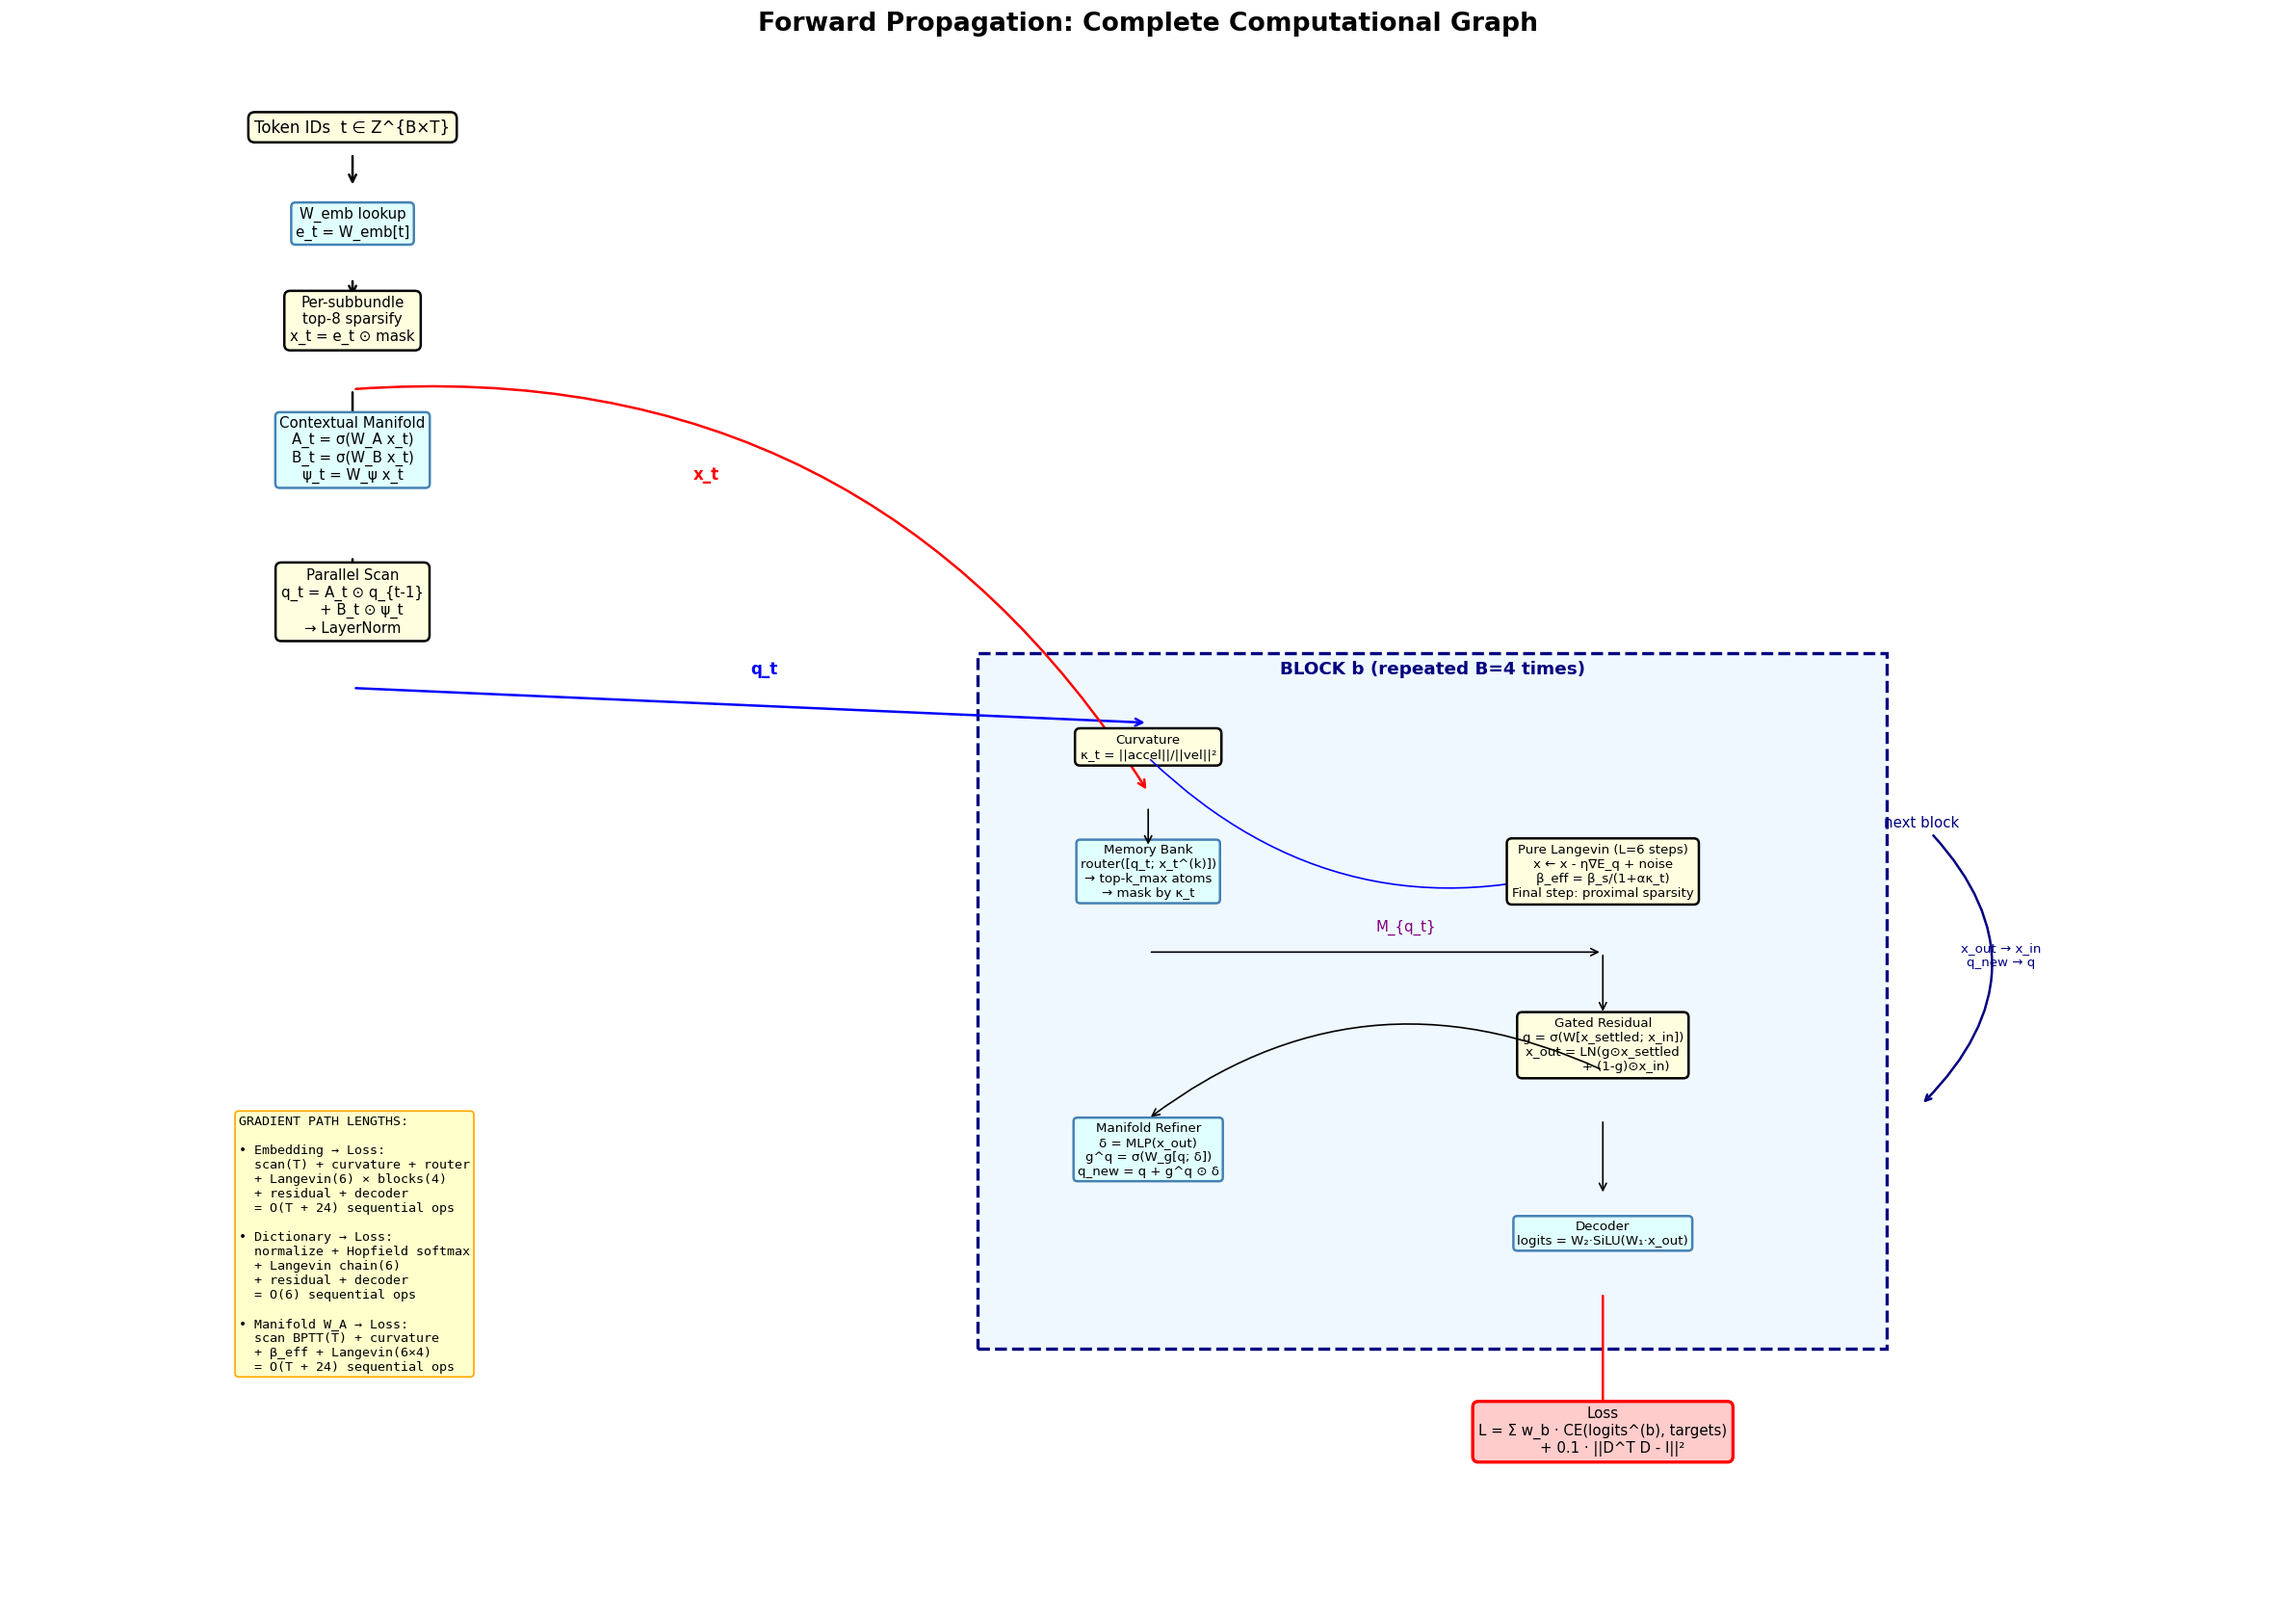

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(20, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 22)
ax.axis('off')
ax.set_title('Forward Propagation: Complete Computational Graph', fontsize=16, fontweight='bold', pad=20)

box_style = dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='black', lw=1.5)
param_style = dict(boxstyle='round,pad=0.3', facecolor='lightcyan', edgecolor='steelblue', lw=1.5)
loss_style = dict(boxstyle='round,pad=0.4', facecolor='#ffcccc', edgecolor='red', lw=2)
note_style = dict(boxstyle='round,pad=0.3', facecolor='#ffffcc', edgecolor='orange', lw=1)

# Stage 1: Embedding
ax.text(3, 21, 'Token IDs  t ∈ Z^{B×T}', fontsize=10, ha='center', bbox=box_style)
ax.annotate('', xy=(3, 20.2), xytext=(3, 20.7), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(3, 19.5, 'W_emb lookup\ne_t = W_emb[t]', fontsize=9, ha='center', bbox=param_style)
ax.annotate('', xy=(3, 18.6), xytext=(3, 18.9), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(3, 18, 'Per-subbundle\ntop-8 sparsify\nx_t = e_t ⊙ mask', fontsize=9, ha='center', bbox=box_style)

# Stage 2: Manifold
ax.annotate('', xy=(3, 16.6), xytext=(3, 17.3), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(3, 16, 'Contextual Manifold\nA_t = σ(W_A x_t)\nB_t = σ(W_B x_t)\nψ_t = W_ψ x_t', fontsize=9, ha='center', bbox=param_style)
ax.annotate('', xy=(3, 14.4), xytext=(3, 14.9), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(3, 13.8, 'Parallel Scan\nq_t = A_t ⊙ q_{t-1}\n    + B_t ⊙ ψ_t\n→ LayerNorm', fontsize=9, ha='center', bbox=box_style)

# Branch: x and q go to block
ax.annotate('', xy=(10, 12.5), xytext=(3, 13), arrowprops=dict(arrowstyle='->', lw=1.5, color='blue'))
ax.text(6.5, 13.2, 'q_t', fontsize=10, color='blue', fontweight='bold')
ax.annotate('', xy=(10, 11.5), xytext=(3, 17.3), arrowprops=dict(arrowstyle='->', lw=1.5, color='red',
            connectionstyle='arc3,rad=-0.3'))
ax.text(6, 16, 'x_t', fontsize=10, color='red', fontweight='bold')

# Block (big box)
block_rect = plt.Rectangle((8.5, 3.5), 8, 10, fill=True, facecolor='#f0f8ff',
                             edgecolor='navy', lw=2, linestyle='--')
ax.add_patch(block_rect)
ax.text(12.5, 13.2, 'BLOCK b (repeated B=4 times)', fontsize=11, ha='center', fontweight='bold', color='navy')

# Inside block: Curvature
ax.text(10, 12, 'Curvature\nκ_t = ||accel||/||vel||²', fontsize=8, ha='center', bbox=box_style)

# Inside block: Memory Bank
ax.text(10, 10, 'Memory Bank\nrouter([q_t; x_t^(k)])\n→ top-k_max atoms\n→ mask by κ_t', fontsize=8, ha='center', bbox=param_style)
ax.annotate('', xy=(10, 10.7), xytext=(10, 11.3), arrowprops=dict(arrowstyle='->', lw=1))
ax.annotate('', xy=(14, 10.5), xytext=(10, 12), arrowprops=dict(arrowstyle='->', lw=1, color='blue', connectionstyle='arc3,rad=0.3'))

# Inside block: Langevin
ax.text(14, 10, 'Pure Langevin (L=6 steps)\nx ← x - η∇E_q + noise\nβ_eff = β_s/(1+ακ_t)\nFinal step: proximal sparsity', fontsize=8, ha='center', bbox=box_style)
ax.annotate('', xy=(14, 9.2), xytext=(10, 9.2), arrowprops=dict(arrowstyle='->', lw=1))
ax.text(12, 9.5, 'M_{q_t}', fontsize=9, color='purple')

# Inside block: Gated Residual
ax.text(14, 7.5, 'Gated Residual\ng = σ(W[x_settled; x_in])\nx_out = LN(g⊙x_settled\n           + (1-g)⊙x_in)', fontsize=8, ha='center', bbox=box_style)
ax.annotate('', xy=(14, 8.3), xytext=(14, 9.2), arrowprops=dict(arrowstyle='->', lw=1))

# Inside block: Manifold Refiner
ax.text(10, 6, 'Manifold Refiner\nδ = MLP(x_out)\ng^q = σ(W_g[q; δ])\nq_new = q + g^q ⊙ δ', fontsize=8, ha='center', bbox=param_style)
ax.annotate('', xy=(10, 6.8), xytext=(14, 7.5), arrowprops=dict(arrowstyle='->', lw=1, connectionstyle='arc3,rad=0.3'))

# Decoder output from block
ax.text(14, 5, 'Decoder\nlogits = W₂·SiLU(W₁·x_out)', fontsize=8, ha='center', bbox=param_style)
ax.annotate('', xy=(14, 5.7), xytext=(14, 6.8), arrowprops=dict(arrowstyle='->', lw=1))

# Deep supervision arrow
ax.annotate('', xy=(14, 2.5), xytext=(14, 4.3), arrowprops=dict(arrowstyle='->', lw=1.5, color='red'))

# Loop arrow for blocks
ax.annotate('next block', xy=(16.8, 7), xytext=(16.8, 11),
            fontsize=9, color='navy', ha='center',
            arrowprops=dict(arrowstyle='->', color='navy', lw=1.5, connectionstyle='arc3,rad=-0.5'))
ax.text(17.5, 9, 'x_out → x_in\nq_new → q', fontsize=8, color='navy', ha='center')

# Loss
ax.text(14, 2, 'Loss\nL = Σ w_b · CE(logits^(b), targets)\n    + 0.1 · ||D^T D - I||²', fontsize=9, ha='center', bbox=loss_style)

# Gradient note
ax.text(2, 5, 'GRADIENT PATH LENGTHS:\n\n• Embedding → Loss:\n  scan(T) + curvature + router\n  + Langevin(6) × blocks(4)\n  + residual + decoder\n  = O(T + 24) sequential ops\n\n• Dictionary → Loss:\n  normalize + Hopfield softmax\n  + Langevin chain(6)\n  + residual + decoder\n  = O(6) sequential ops\n\n• Manifold W_A → Loss:\n  scan BPTT(T) + curvature\n  + β_eff + Langevin(6×4)\n  = O(T + 24) sequential ops',
        fontsize=8, ha='left', va='center', bbox=note_style, family='monospace')

plt.tight_layout()
plt.show()

### 8.9 Backpropagation — Gradient Flow Through Each Parameter Group

The total loss $\mathcal{L}$ is differentiated with respect to every learned parameter. We trace the gradient path for each parameter group, identifying where signal is strong, where it vanishes, and where it creates pathological incentives.

---

**Parameter Group 1: Embedding matrix $W_{\text{emb}} \in \mathbb{R}^{V \times D}$**

$$\frac{\partial \mathcal{L}}{\partial W_{\text{emb}}} = \sum_{t=0}^{T-1} \frac{\partial \mathcal{L}}{\partial x_t} \cdot \frac{\partial x_t}{\partial e_t} \cdot \frac{\partial e_t}{\partial W_{\text{emb}}}$$

The term $\partial x_t / \partial e_t = \text{diag}(\mathbf{1}_{S_t})$ is the sparsity mask. Only 64 of 256 dimensions get gradient (8 active per subbundle × 8 subbundles). The gradient is **sparse by construction**.

The gradient $\partial \mathcal{L}/\partial x_t$ includes contributions from:
- The direct Langevin settling path (through all blocks)
- The manifold path (through $W_A, W_B, W_\psi$ projections, then through all downstream curvature and routing)

Both paths contribute, but the manifold path passes through $T$ sequential scan steps, causing significant gradient attenuation for early positions.

---

**Parameter Group 2: Manifold projections $W_A, W_B, W_\psi \in \mathbb{R}^{d_m \times D}$**

The gradient flows backward through the parallel scan via BPTT:

$$\frac{\partial \mathcal{L}}{\partial W_A} = \sum_{t=0}^{T-1} \frac{\partial \mathcal{L}}{\partial q_t} \cdot \frac{\partial q_t}{\partial A_t} \cdot \sigma'(W_A x_t) \cdot x_t^\top$$

where the chain through the scan gives:

$$\frac{\partial \mathcal{L}}{\partial q_t} = \frac{\partial \mathcal{L}_{\text{local}}}{\partial q_t} + A_{t+1} \odot \frac{\partial \mathcal{L}}{\partial q_{t+1}}$$

This is the standard BPTT recurrence. The "local" gradient at position $t$ comes from:
1. The memory bank router (which takes $q_t$ as input)
2. The curvature computation (which depends on $q_{t-1}, q_t, q_{t+1}$)
3. The curvature-modulated $\beta_s^{\text{eff}}$ (which depends on $\kappa_t$)

The key insight: **$W_A$ is the most important parameter group**, because it controls how much history is retained. But it also has the longest gradient path (BPTT through $T$ steps). The bias $b_A$ initialization (uniform in $[-2, 2]$) creates sigmoid outputs ranging from $\sigma(-2) \approx 0.12$ to $\sigma(2) \approx 0.88$, providing multi-scale gradient horizons.

---

**Parameter Group 3: Dictionary atoms $D^{(k)} \in \mathbb{R}^{N_{\text{atoms}} \times d}$**

$$\frac{\partial \mathcal{L}}{\partial D^{(k)}} = \frac{\partial \mathcal{L}}{\partial \hat{D}^{(k)}} \cdot \frac{\partial \hat{D}^{(k)}}{\partial D^{(k)}} + 0.1 \cdot \frac{\partial \mathcal{L}_{\text{dict}}}{\partial D^{(k)}}$$

The first term flows through the Langevin chain: the dictionary atoms appear in the Hopfield gradient $\nabla_x E_q = -\sum_j w_j m_j$. The gradient with respect to atom $m_j$ is:

$$\frac{\partial \nabla_x E_q}{\partial m_j} = -w_j \cdot I - \beta \cdot w_j (x^\top m_j - x^\top \bar{m}) \cdot x \cdot \mathbf{e}_j^\top$$

where $\mathbf{e}_j$ is a basis vector and $\bar{m} = \sum_j w_j m_j$.

The dictionary atoms have the **shortest gradient path** to the loss (through the Langevin chain, which is only 6 steps per block). They learn the fastest and most directly.

The coherence regularizer $\partial \mathcal{L}_{\text{dict}} / \partial D^{(k)}$ pushes atoms toward mutual orthogonality, preventing collapse to a few dominant atoms.

---

**Parameter Group 4: Router weights $W_1^{(k)}, W_2^{(k)}$**

The router selects which atoms are active. Its gradient flows through:

$$\frac{\partial \mathcal{L}}{\partial W_{\text{router}}} = \sum_t \frac{\partial \mathcal{L}}{\partial M_t^{(k)}} \cdot \frac{\partial M_t^{(k)}}{\partial I_t^{(k)}} \cdot \frac{\partial I_t^{(k)}}{\partial \ell_t^{(k)}} \cdot \frac{\partial \ell_t^{(k)}}{\partial W_{\text{router}}}$$

The `argtop-k` derivative $\partial I / \partial \ell$ is technically zero (discrete selection), but PyTorch's autograd flows gradients through the selected atoms' values, providing an implicit straight-through gradient. The router learns which atoms to select for which (context, token) pairs.

---

**Parameter Group 5: Residual gate $W_{\text{gate}} \in \mathbb{R}^{D \times 2D}$**

$$\frac{\partial \mathcal{L}}{\partial W_{\text{gate}}} = \sum_t \frac{\partial \mathcal{L}}{\partial x_t^{\text{out}}} \cdot (x_t^{\text{settled}} - x_t^{\text{in}}) \cdot \sigma'(\cdot) \cdot [x_t^{\text{settled}}; x_t^{\text{in}}]^\top$$

The gate gradient is proportional to the *difference* between settled and input representations. If $x_t^{\text{settled}} \approx x_t^{\text{in}}$ (settling changed nothing), the gate gradient vanishes. The gate learns the most when settling produces representations that differ significantly from the input.

---

**Parameter Group 6: Manifold refiner $W_{\text{ref1}}, W_{\text{ref2}}, W_g$**

The refiner receives gradients from all subsequent blocks (because $q^{(b+1)}$ depends on the refiner output of block $b$). This creates a **telescoping gradient**:

$$\frac{\partial \mathcal{L}}{\partial W_{\text{ref}}^{(b)}} = \sum_{b'=b+1}^{B-1} \frac{\partial \mathcal{L}^{(b')}}{\partial q^{(b+1)}} \cdot \frac{\partial q^{(b+1)}}{\partial W_{\text{ref}}^{(b)}}$$

Block 0's refiner gets gradient from blocks 1, 2, and 3. Block 3's refiner gets gradient only from the final loss. Earlier refiners have richer gradient signals but longer paths.

---

**Parameter Group 7: Decoder $W_{\text{dec1}}, W_{\text{dec2}}$**

The decoder has the simplest gradient — direct from the CE loss:

$$\frac{\partial \mathcal{L}}{\partial W_{\text{dec}}} = \sum_b w_b \sum_t (\hat{p}_t - \mathbf{e}_{x_{t+1}}) \cdot \frac{\partial \text{logits}_t}{\partial W_{\text{dec}}}$$

where $\hat{p}_t = \text{softmax}(\text{logits}_t)$ and $\mathbf{e}_{x_{t+1}}$ is the one-hot target. The decoder adapts fastest because it has the most direct gradient path.

---

### 8.10 The Weight Update

AdamW computes the parameter update for each parameter $\theta$:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \qquad \text{(first moment)}$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \qquad \text{(second moment)}$$

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \qquad \text{(bias correction)}$$

$$\theta_{t+1} = \theta_t - \eta \left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda_{\text{wd}} \cdot \theta_t\right)$$

where $\eta = 3 \times 10^{-4}$, $\lambda_{\text{wd}} = 0.01$, $\beta_1 = 0.9$, $\beta_2 = 0.999$.

**Gradient clipping** is applied before the Adam step:

$$g \leftarrow g \cdot \min\!\left(1,\; \frac{1}{\|g\|}\right) \qquad \text{(max norm = 1.0)}$$

This prevents the Langevin chain's potential gradient explosion from destabilizing training.

---

### 8.11 Summary: What Each Component Learns

| Component | What It Learns | Gradient Path Length | Primary Signal |
|---|---|---|---|
| $W_{\text{emb}}$ | Token representations | $O(T + 24)$ | Sparse (75% dead dims) |
| $W_A$ (retention) | How much history to keep | $O(T)$ BPTT | Vanishes for early positions |
| $W_B$ (input gate) | How much new token to add | $O(T)$ BPTT | Same vanishing issue |
| $W_\psi$ (projection) | How tokens map to manifold | $O(T)$ BPTT | Same vanishing issue |
| $D^{(k)}$ (atoms) | Attractor positions | $O(6)$ per block | Strong, direct signal |
| $W_{\text{router}}$ | Which atoms for which context | $O(6)$ per block | Implicit straight-through |
| $W_{\text{gate}}$ | Settle vs preserve ratio | $O(1)$ | Proportional to settle change |
| $W_{\text{ref}}$ | Manifold refinement | $O(B-b)$ blocks | Telescoping from later blocks |
| $W_{\text{dec}}$ | Representation → logits | $O(1)$ | Strongest, most direct |

**The learning hierarchy:** Decoder adapts fastest → Dictionary atoms → Router → Gate → Manifold projections (slowest). This means the manifold (the most important component) learns the slowest and with the weakest signal.

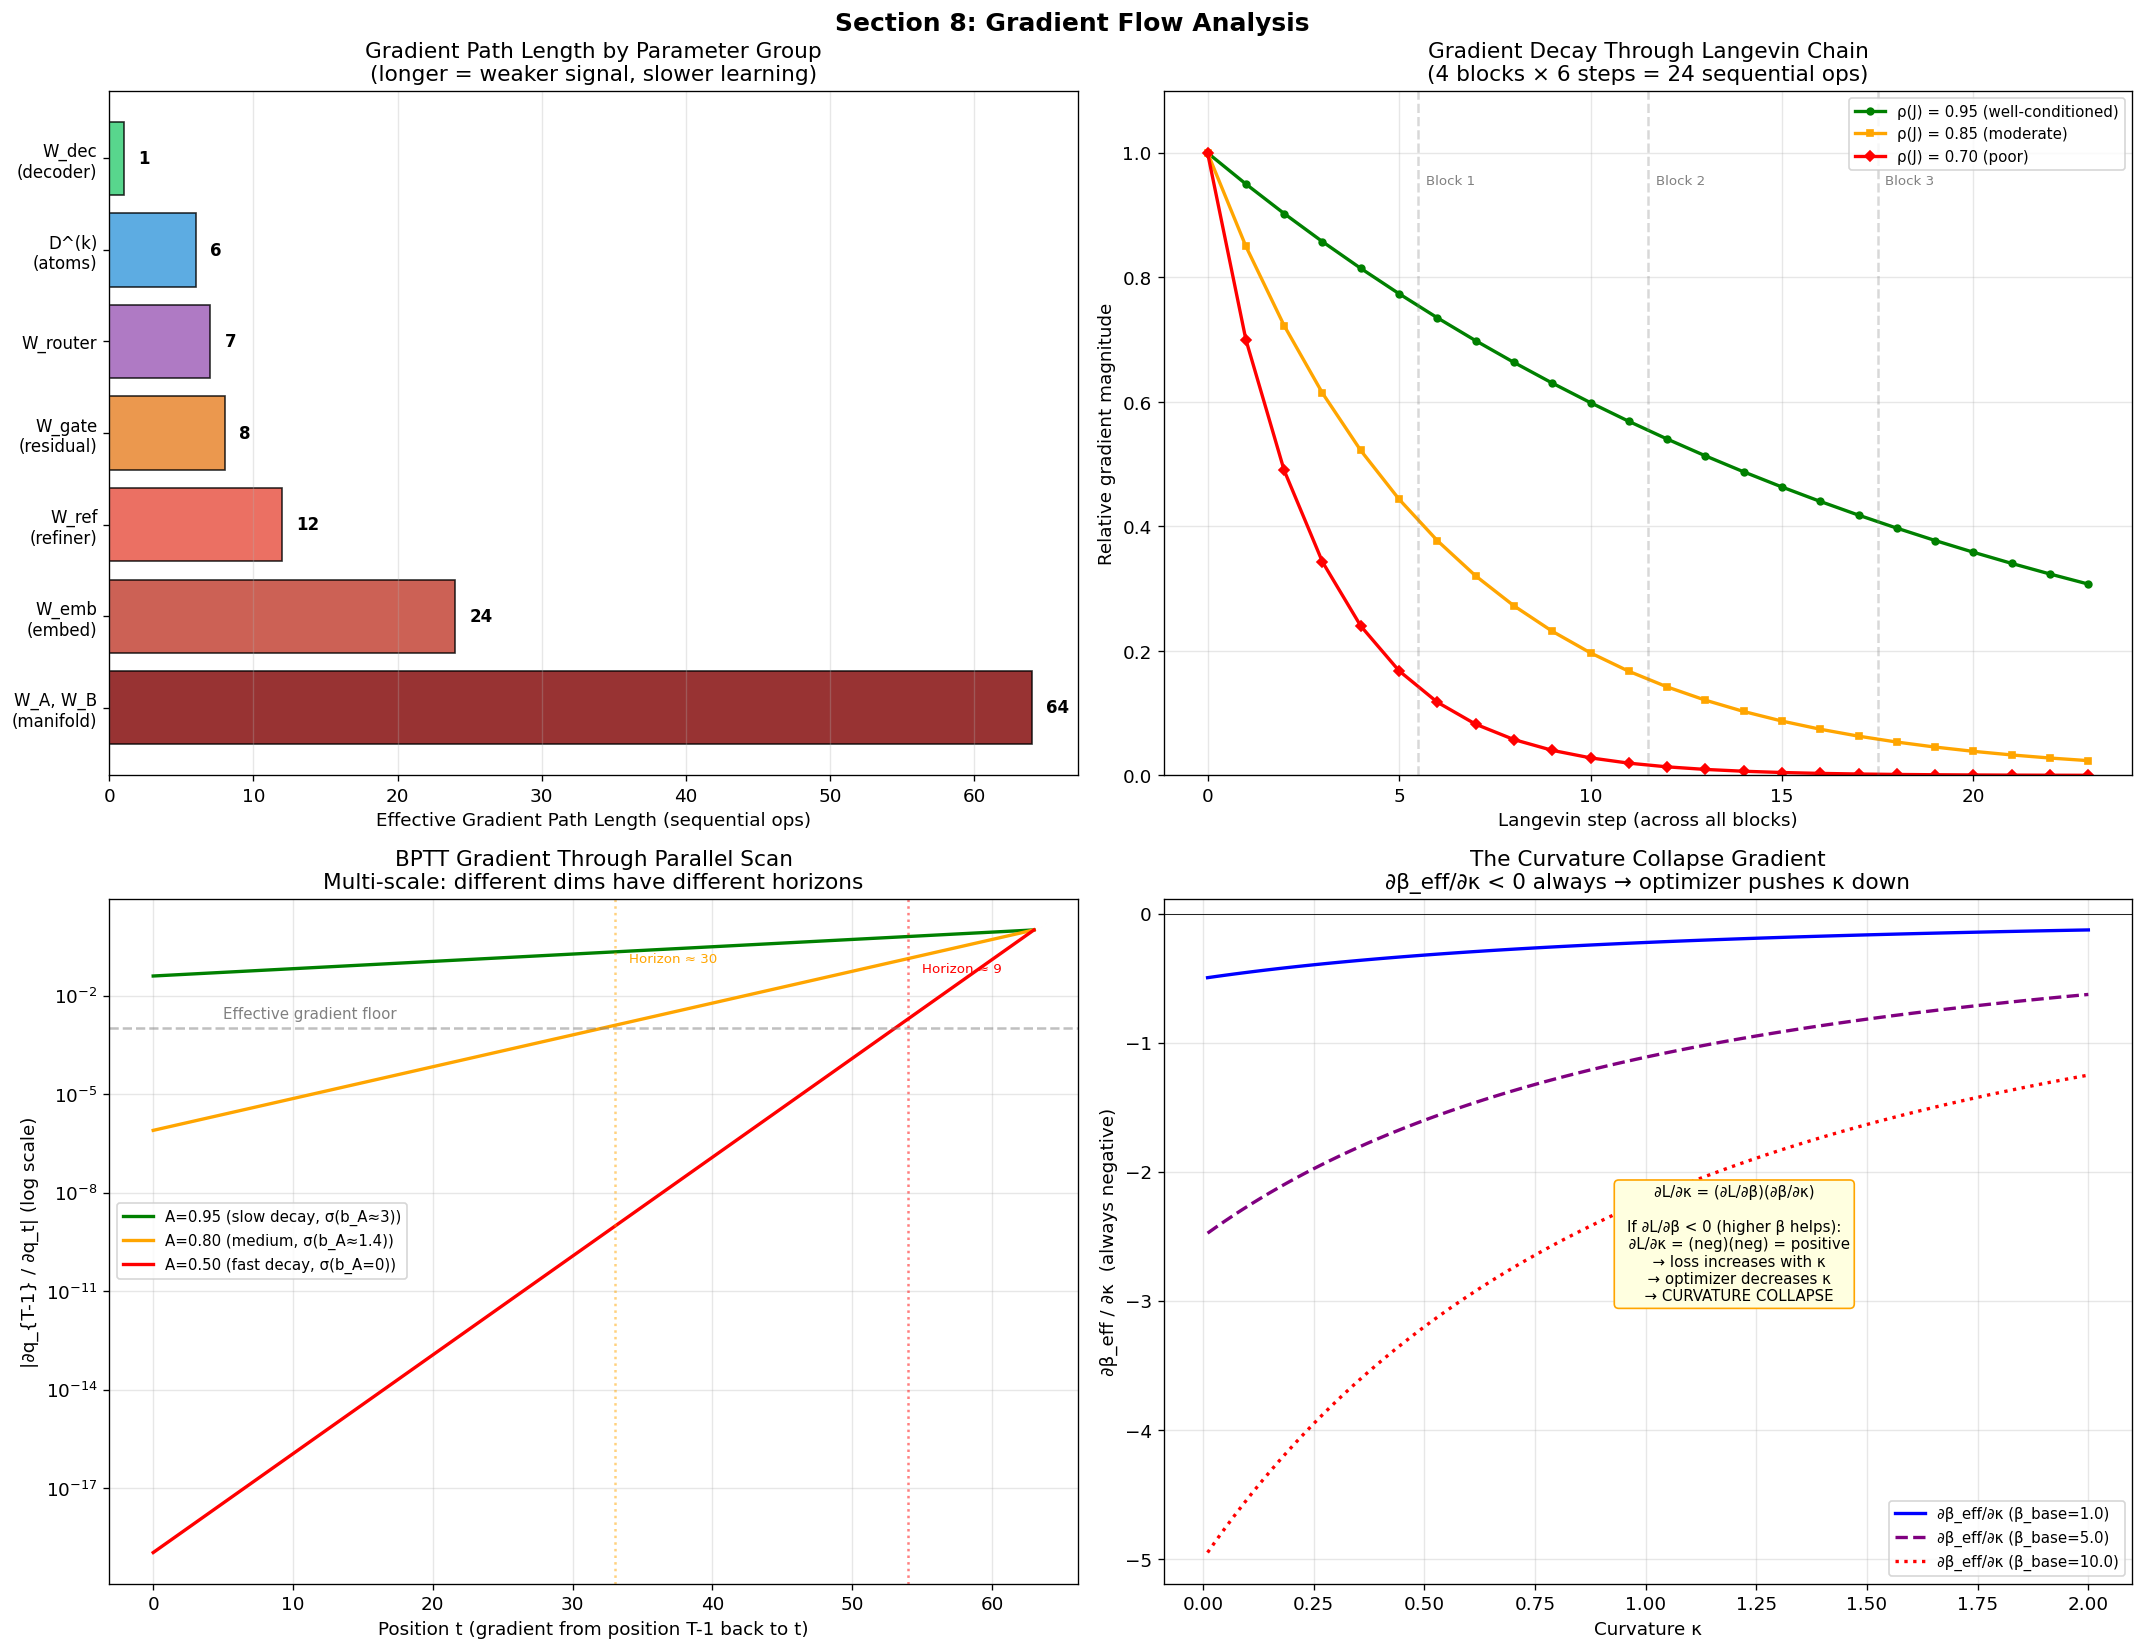

KEY FINDING: The manifold parameters (W_A, W_B, W_ψ) have the
longest gradient path AND suffer from BPTT vanishing gradients.
They learn the slowest. Meanwhile, the curvature collapse gradient
(∂β_eff/∂κ) provides a systematic, short-path pressure toward
flatness. The manifold can't learn fast enough to resist collapse.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Panel 1: Gradient path lengths by parameter group ---
ax = axes[0, 0]

param_groups = [
    ('W_dec\n(decoder)', 1, '#2ecc71'),
    ('D^(k)\n(atoms)', 6, '#3498db'),
    ('W_router', 7, '#9b59b6'),
    ('W_gate\n(residual)', 8, '#e67e22'),
    ('W_ref\n(refiner)', 12, '#e74c3c'),
    ('W_emb\n(embed)', 24, '#c0392b'),
    ('W_A, W_B\n(manifold)', 64, '#7f0000'),
]

names = [p[0] for p in param_groups]
lengths = [p[1] for p in param_groups]
colors = [p[2] for p in param_groups]

bars = ax.barh(range(len(param_groups)), lengths, color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(param_groups)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Effective Gradient Path Length (sequential ops)')
ax.set_title('Gradient Path Length by Parameter Group\n(longer = weaker signal, slower learning)')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

for bar, length in zip(bars, lengths):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{length}', va='center', fontsize=10, fontweight='bold')

# --- Panel 2: Gradient magnitude decay through Langevin chain ---
ax = axes[0, 1]

L_steps = 6
n_blocks = 4
total_steps = L_steps * n_blocks

# Model gradient decay through chained Langevin
# Jacobian spectral radius per step (hypothetical)
step_indices = np.arange(total_steps)

# Scenario 1: Well-conditioned (Jacobian spectral radius ~0.95)
grad_good = 0.95 ** step_indices
# Scenario 2: Moderate (0.85)
grad_moderate = 0.85 ** step_indices
# Scenario 3: Poor (0.7)
grad_poor = 0.7 ** step_indices

ax.plot(step_indices, grad_good, 'g-o', ms=4, lw=2, label='ρ(J) = 0.95 (well-conditioned)')
ax.plot(step_indices, grad_moderate, 'orange', marker='s', ms=4, lw=2, label='ρ(J) = 0.85 (moderate)')
ax.plot(step_indices, grad_poor, 'r-D', ms=4, lw=2, label='ρ(J) = 0.70 (poor)')

for b in range(1, n_blocks):
    ax.axvline(x=b * L_steps - 0.5, color='gray', linestyle='--', alpha=0.3)
    ax.text(b * L_steps - 0.3, 0.95, f'Block {b}', fontsize=8, color='gray')

ax.set_xlabel('Langevin step (across all blocks)')
ax.set_ylabel('Relative gradient magnitude')
ax.set_title('Gradient Decay Through Langevin Chain\n(4 blocks × 6 steps = 24 sequential ops)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)

# --- Panel 3: BPTT gradient through parallel scan ---
ax = axes[1, 0]

T = 64
# Retention gate values (different for different manifold dimensions)
np.random.seed(42)
A_slow = 0.95  # slow decay dimension
A_fast = 0.5   # fast decay dimension
A_medium = 0.8

positions = np.arange(T)

# Gradient magnitude from position T-1 back to position t
grad_slow = A_slow ** (T - 1 - positions)
grad_fast = A_fast ** (T - 1 - positions)
grad_medium = A_medium ** (T - 1 - positions)

ax.semilogy(positions, grad_slow, 'g-', lw=2, label=f'A=0.95 (slow decay, σ(b_A≈3))')
ax.semilogy(positions, grad_medium, 'orange', lw=2, label=f'A=0.80 (medium, σ(b_A≈1.4))')
ax.semilogy(positions, grad_fast, 'r-', lw=2, label=f'A=0.50 (fast decay, σ(b_A=0))')

ax.axhline(y=1e-3, color='gray', linestyle='--', alpha=0.5)
ax.text(5, 2e-3, 'Effective gradient floor', fontsize=9, color='gray')

ax.set_xlabel('Position t (gradient from position T-1 back to t)')
ax.set_ylabel('|∂q_{T-1} / ∂q_t| (log scale)')
ax.set_title('BPTT Gradient Through Parallel Scan\nMulti-scale: different dims have different horizons')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Mark effective gradient horizon for each
for A_val, color, y_pos in [(A_slow, 'green', 0.15), (A_medium, 'orange', 0.1), (A_fast, 'red', 0.05)]:
    horizon = int(np.log(1e-3) / np.log(A_val))
    if horizon < T:
        ax.axvline(x=T - 1 - horizon, color=color, linestyle=':', alpha=0.5)
        ax.text(T - 1 - horizon + 1, y_pos, f'Horizon ≈ {horizon}', fontsize=8, color=color)

# --- Panel 4: Curvature collapse gradient mechanism ---
ax = axes[1, 1]

kappa_range = np.linspace(0.01, 2.0, 100)
alpha = 0.5

# For different beta_base values
for beta_base, color, ls in [(1.0, 'blue', '-'), (5.0, 'purple', '--'), (10.0, 'red', ':')]:
    beta_eff = beta_base / (1 + alpha * kappa_range)
    d_beta_d_kappa = -alpha * beta_base / (1 + alpha * kappa_range)**2

    ax.plot(kappa_range, d_beta_d_kappa, color=color, lw=2, linestyle=ls,
            label=f'∂β_eff/∂κ (β_base={beta_base})')

ax.axhline(y=0, color='black', lw=0.5)
ax.set_xlabel('Curvature κ')
ax.set_ylabel('∂β_eff / ∂κ  (always negative)')
ax.set_title('The Curvature Collapse Gradient\n∂β_eff/∂κ < 0 always → optimizer pushes κ down')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotation
ax.annotate('∂L/∂κ = (∂L/∂β)(∂β/∂κ)\n\nIf ∂L/∂β < 0 (higher β helps):\n  ∂L/∂κ = (neg)(neg) = positive\n  → loss increases with κ\n  → optimizer decreases κ\n  → CURVATURE COLLAPSE',
            xy=(1.2, -3), fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.suptitle('Section 8: Gradient Flow Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("KEY FINDING: The manifold parameters (W_A, W_B, W_ψ) have the")
print("longest gradient path AND suffer from BPTT vanishing gradients.")
print("They learn the slowest. Meanwhile, the curvature collapse gradient")
print("(∂β_eff/∂κ) provides a systematic, short-path pressure toward")
print("flatness. The manifold can't learn fast enough to resist collapse.")

## 9. Summary of the Mathematical Framework

### The Architecture in One Diagram

```
Token sequence: x_0, x_1, ..., x_T
        |
        v
[Sparse Fiber Sections]  (Axiom 1)
  Per-subbundle top-k sparsification
  x_sparse in F_q^(1) + ... + F_q^(K)
        |
        v
[Contextual Manifold]  (Wilson Line / SSM)
  q_t = A(x_t) * q_{t-1} + B(x_t) * psi(x_t)
  Content-dependent, path-dependent coordinates
        |
        v
For each block b = 0, 1, ..., B-1:
  |
  |-->[Curvature Computation]
  |     kappa_t = ||accel|| / ||vel||^2
  |
  |-->[Curvature-Aware Memory Bank]  (Axiom 3)
  |     k_t = k_min + kappa_norm * (k_max - k_min)
  |     M_{q_t} = top-k_t atoms from Dictionary[subbundle]
  |
  |-->[Pure Langevin Descent]  (Axiom 4)
  |     dx = -grad E_q(x; M_{q_t}) dt + sqrt(2/beta_t) dW
  |     beta_effective = beta_base / (1 + alpha * kappa_t)
  |     Final step: proximal sparsity (Axiom 5)
  |
  |-->[Manifold Refinement]
  |     q' = q + gate(q, delta(x_settled)) * delta(x_settled)
  |     (Cooperative geometry construction, Gurnee et al.)
  |
  |-->[Gated Residual]
        x_out = gate * x_settled + (1-gate) * x_in
        |
        v
[Decoder] -> logits -> CE loss (deep supervision from all blocks)
```

### Mathematical Objects and Their Roles

| Mathematical Object | Architectural Component | Role |
|---|---|---|
| Base manifold M | Contextual manifold coordinates q_t | "Where in meaning space" |
| Fiber F_q | Token representation at coordinate q | "What the token encodes here" |
| Subbundle decomposition | K orthogonal subspaces | Factored, compositional structure |
| Gauge connection A | SSM transition A(x_t) | Content-dependent context dynamics |
| Wilson line / holonomy | Parallel scan output q_T | Accumulated sequence context |
| Curvature Omega | Discrete kappa_t | Measures context change rate |
| Hopfield energy E_q | Memory bank attractors M_{q_t} | Context-shaped landscape |
| Langevin SDE | Gradient descent + noise | Settling into attractor |
| Proximal operator | Soft-thresholding | Biological lateral inhibition |
| Place cells (Gurnee) | Memory bank atoms | Tile the manifold with features |
| Holonomy (Thm 4.1) | Path-dependent q_t | Order of tokens matters |

### Key Findings from the Audit

1. The mathematical framework is sound — each component has a clear formal role
2. The contextual manifold DOES produce content-dependent coordinates (kappa > 0)
3. But curvature collapses during training (0.19 → 0.03), a geometric mode collapse
4. The pure SDE hypothesis (no cross-position forces) is too aggressive at ~2.5M params
5. The manifold needs structural support (curvature regularization, gradient detachment)
   to maintain its geometry under optimization pressure

### The Mathematical Lesson

The architecture instantiates a beautiful correspondence between gauge theory and
sequence modeling. But mathematical beauty does not guarantee trainability.
The optimization landscape can find degenerate solutions (flat manifolds) that
satisfy the loss locally while abandoning the geometric structure that would
enable better generalization. The next iteration must add inductive biases that
*protect* the geometry from optimization pressure — much as weight decay protects
against overfitting, curvature regularization would protect against geometric collapse.

---

*Mathematical companion to architecture_v10_1.ipynb. March 2026.*